# COSC2753 Assignment 2 - Fashion Intelligence System
### Task 2 - `season` Classification
### Objective: Develop a model to predict "season" class
Vu Quoc Gia Quan - s3927120

## Part I - Load the preprocessed data

### What is loaded, and what is rebuilt

Loaded straight from save:

| Artifact | File |
|---|---|
| Full cleaned train/validation split | "train_full.csv", "val_full.csv" |
| Per-task usable subsets (target non-null, encoded) | "holdout_metadata/{target}_{train,val}.csv" |
| Fitted "LabelEncoder" per target | "label_encoders.pkl" |
| Image size, normalisation constants, thresholds, seed | "pipeline_config.json" |

Rebuilt in code, because they are not serialisable objects:

- "train_transform" / "eval_transform" - torchvision transforms hold a lambda-free but
  still unpicklable graph. They are reconstructed from the "normalization_mean" and
  "normalization_std" recorded in "pipeline_config.json", so they are numerically identical
  to the ones used to compute those statistics, not merely similar.
- "FashionImageDataset", "get_weighted_sampler" - ordinary class and function definitions.


In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from torch.utils.data import Dataset, WeightedRandomSampler
from torchvision import transforms as T
from sklearn.preprocessing import LabelEncoder

DATA_DIR = Path("../data/raw/FashionDataset")
OUT_DIR = Path("../data/processed")

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR = DATA_DIR / "test" / "images_test"
# Check that the required files exist, otherwise raise an error
REQUIRED = {
    "config":       OUT_DIR / "pipeline_config.json",
    "encoders":     OUT_DIR / "label_encoders.pkl",
    "train_full":   OUT_DIR / "train_full.csv",
    "val_full":     OUT_DIR / "val_full.csv",
    "holdout_dir":  OUT_DIR / "holdout_metadata",
}
missing = {k: v for k, v in REQUIRED.items() if not v.exists()}
for name, path in REQUIRED.items():
    print(f"[{'OK' if path.exists() else 'MISSING':>7}] {name:12s} {path}")
if missing:
    raise FileNotFoundError(
        "Run COSC2753_A2_Preprocessing.ipynb first -- it writes the files above. "
        f"Missing: {list(missing)}")

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING':>7}] {p}")

with open(REQUIRED["config"]) as f:
    config = json.load(f)
# Set random seeds and image parameters from config
RANDOM_STATE = config["random_state"]
IMG_WIDTH = config["image"]["width"]
IMG_HEIGHT = config["image"]["height"]
mean = torch.tensor(config["image"]["normalization_mean"])
std = torch.tensor(config["image"]["normalization_std"])
ARTICLE_TYPE_MIN_COUNT = config["rare_class_thresholds"]["articleType"]
USAGE_MIN_COUNT = config["rare_class_thresholds"]["usage"]

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"\nSeed {RANDOM_STATE} | images {IMG_HEIGHT}x{IMG_WIDTH} (HxW)")
print(f"Normalisation mean {[round(v, 4) for v in mean.tolist()]}, "
      f"std {[round(v, 4) for v in std.tolist()]}")
print(f"Rare-class thresholds: articleType>={ARTICLE_TYPE_MIN_COUNT}, usage>={USAGE_MIN_COUNT}")

[     OK] config       ../data/processed/pipeline_config.json
[     OK] encoders     ../data/processed/label_encoders.pkl
[     OK] train_full   ../data/processed/train_full.csv
[     OK] val_full     ../data/processed/val_full.csv
[     OK] holdout_dir  ../data/processed/holdout_metadata
[     OK] ../data/raw/FashionDataset/train/styles_train.csv
[     OK] ../data/raw/FashionDataset/train/images_train
[     OK] ../data/raw/FashionDataset/test/styles_prediction.csv
[     OK] ../data/raw/FashionDataset/test/images_test

Seed 42 | images 80x60 (HxW)
Normalisation mean [0.8476, 0.8307, 0.8243], std [0.274, 0.285, 0.2889]
Rare-class thresholds: articleType>=20, usage>=100


In [2]:

ID_DTYPE = {"id": str}

train_data = pd.read_csv(OUT_DIR / "train_full.csv", dtype=ID_DTYPE)
val_data = pd.read_csv(OUT_DIR / "val_full.csv", dtype=ID_DTYPE)

with open(OUT_DIR / "label_encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

holdout_dir = OUT_DIR / "holdout_metadata"
train_usable, val_usable = {}, {}
for t in encoders:
    train_usable[t] = pd.read_csv(holdout_dir / f"{t}_train.csv", dtype=ID_DTYPE)
    val_usable[t] = pd.read_csv(holdout_dir / f"{t}_val.csv", dtype=ID_DTYPE)

target_columns = {}
for t in encoders:
    candidates = [f"{t}_grouped", t]
    col = next((c for c in candidates
                if c in train_usable[t].columns and f"{c}_enc" in train_usable[t].columns), None)
    if col is None:
        raise KeyError(
            f"{t}: no encoded target column found. Looked for "
            f"{[c + '_enc' for c in candidates]} in {holdout_dir / f'{t}_train.csv'}. "
            "Re-run the preprocessing notebook to regenerate the holdout files.")
    target_columns[t] = col

df = pd.concat([train_data, val_data], ignore_index=True)

print(f"train_full: {train_data.shape}   val_full: {val_data.shape}   combined: {df.shape}")
print("\nPer-task usable subsets:")
for t, col in target_columns.items():
    print(f"  {t:12s} -> column {col:20s} train={len(train_usable[t]):>6}  "
          f"val={len(val_usable[t]):>6}  classes={len(encoders[t].classes_):>3}")

# --- integrity checks: the saved split must still be a valid split -----------
assert set(train_data["id"]).isdisjoint(set(val_data["id"])), "id overlap between train and val"
assert set(train_data["dup_group"]).isdisjoint(set(val_data["dup_group"])), \
    "duplicate-image group spans the split"
assert df["id"].is_unique, "duplicate ids in the reloaded data"
for t, col in target_columns.items():
    enc_col = f"{col}_enc"
    n_cls = len(encoders[t].classes_)
    for name, frame in (("train", train_usable[t]), ("val", val_usable[t])):
        assert frame[col].notna().all(), f"{t}: null target in {name}"
        assert frame[enc_col].notna().all(), f"{t}: missing encoded label in {name}"
        assert frame[enc_col].between(0, n_cls - 1).all(), f"{t}: encoded label out of range in {name}"
        assert set(frame[col]).issubset(set(encoders[t].classes_)), \
            f"{t}: {name} contains a class the encoder never saw"
        # The encoded column must actually agree with the encoder, not merely be in range --
        # a stale CSV paired with a newer pickle would pass every check above.
        assert (encoders[t].transform(frame[col]) == frame[enc_col].to_numpy()).all(), \
            f"{t}: {enc_col} disagrees with label_encoders.pkl -- re-run preprocessing"
print("\nIntegrity checks passed: split is disjoint, ids unique, labels in range.")

train_full: (28371, 13)   val_full: (9457, 13)   combined: (37828, 13)

Per-task usable subsets:
  articleType  -> column articleType_grouped  train= 28371  val=  9455  classes= 95
  season       -> column season               train= 28357  val=  9451  classes=  4
  gender       -> column gender               train= 28371  val=  9457  classes=  5
  usage        -> column usage_grouped        train= 28315  val=  9442  classes=  5

Integrity checks passed: split is disjoint, ids unique, labels in range.


In [3]:
def to_rgb(img):
    """Converts the 249 grayscale ('L' mode) files to 3-channel. A module-level function,
    not a lambda, so the transform stays picklable for DataLoader(num_workers>0)."""
    return img.convert("RGB")


# Evaluation pipeline: no augmentation, so it stays a faithful evaluation signal.
eval_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

# Training pipeline: augmentations to reduce overfitting and normalise to the same mean and std as the evaluation pipeline.
train_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10, fill=255),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])


class FashionImageDataset(Dataset):
    """(image, label) pairs. `target_col` names an already-encoded integer column."""

    def __init__(self, dataframe, images_dir, target_col, transform):
        self.data = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        return img, int(row[self.target_col])


def get_weighted_sampler(data, target_col):
    """Inverse-frequency WeightedRandomSampler. Train split only -- never apply to
    validation, which must keep the real class distribution to stay a fair estimate."""
    counts = data[target_col].value_counts()
    weights = torch.tensor(
        data[target_col].map(lambda c: 1.0 / counts[c]).to_numpy(dtype="float64"),
        dtype=torch.double
    )
    return WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)


# Class weights, computed for reference. Imbalance is handled by the sampler, but the weights are still useful for loss functions that accept them.
class_weights = {}
for t, col in target_columns.items():
    vc = train_usable[t][col].value_counts()
    n_samples, n_classes = len(train_usable[t]), len(encoders[t].classes_)
    w = n_samples / (n_classes * vc)
    class_weights[t] = torch.tensor([w[c] for c in encoders[t].classes_], dtype=torch.float32)

# Verify the reconstructed pipeline against a real image before anything depends on it.
_probe_id = train_data["id"].iloc[0]
_probe = eval_transform(Image.open(IMAGES_TRAIN_DIR / f"{_probe_id}.jpg"))
assert _probe.shape == (3, IMG_HEIGHT, IMG_WIDTH), f"unexpected tensor shape {tuple(_probe.shape)}"
print(f"Transform check: image {_probe_id} -> tensor {tuple(_probe.shape)}, "
      f"range [{_probe.min():.2f}, {_probe.max():.2f}]")
print("Ready: train_data, val_data, df, train_usable, val_usable, encoders,")
print("       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler")

Transform check: image 1163 -> tensor (3, 80, 60), range [-3.05, 0.61]
Ready: train_data, val_data, df, train_usable, val_usable, encoders,
       train_transform, eval_transform, FashionImageDataset, get_weighted_sampler


## Part II - Task 2

## Task 2: Fashion season classification

In [4]:
# season rows from the single shared masterCategory-stratified split (not a separate split). Already contain season_enc.
task2_train = train_usable['season'].copy()
task2_val = val_usable['season'].copy()

assert 'season_enc' in task2_train.columns
assert 'season_enc' in task2_val.columns
print(f'Task 2 train: {len(task2_train):,}; validation: {len(task2_val):,}')
print('Season classes:', encoders['season'].classes_.tolist())

Task 2 train: 28,357; validation: 9,451
Season classes: ['Fall', 'Spring', 'Summer', 'Winter']


In [5]:
print(task2_train.columns.tolist())

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'dup_group', 'articleType_grouped', 'usage_grouped', 'season_enc']


### a) Tabular data preprocessing

Image preprocessing will be the same as task 1  
Metadata needs to be pre-processed since it was used in multi-input models. For categorical attributes, missing values will be imputed using mode. Then the data will be encoded using one-hot encoder (Potdar et al., 2017). On the other hand, categorical data will go through mode imputation while numerical data will go through median imputation because it is resistant to outlier (Kelleher et al., 2020, p. 346). The target attribute “season” had 13 missing values and will be dropped instead of imputed. This was done to make sure no artificial bias will be introduced into the dataset. The target attribute is then encoded to numerical label so machine learning models can predict them.  


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             accuracy_score, f1_score, confusion_matrix)
import joblib

TASK2_TARGET = 'season'
META_FEATURES = ['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'year', 'usage']
META_CAT = [c for c in META_FEATURES if c != 'year']
META_NUM = ['year']

assert task2_train[TASK2_TARGET].notna().all() and task2_val[TASK2_TARGET].notna().all()
assert set(task2_val[TASK2_TARGET]).issubset(set(task2_train[TASK2_TARGET]))

X_train = task2_train[META_FEATURES].copy()
X_val = task2_val[META_FEATURES].copy()
# Convert pandas nullable values to NumPy-compatible missing values for sklearn.
for frame in (X_train, X_val):
    for col in META_CAT:
        frame[col] = frame[col].astype(object).where(frame[col].notna(), np.nan)
    frame['year'] = pd.to_numeric(frame['year'], errors='coerce')

# Preprocessor to handle missing values, encoding categorical features and scaling numerical features for ablation testing.
meta_preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), META_CAT),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), META_NUM)
])
meta_train = meta_preprocessor.fit_transform(X_train).astype('float32')
meta_val = meta_preprocessor.transform(X_val).astype('float32')

# Reuse the season encoder already fit in Section 6.5 -- no need for a second one.
season_encoder = encoders['season']
y_train = task2_train['season_enc'].to_numpy()
y_val = task2_val['season_enc'].to_numpy()

print('Metadata train shape:', meta_train.shape)
print('Metadata validation shape:', meta_val.shape)
print('Encoded target shapes:', y_train.shape, y_val.shape)

Metadata train shape: (28357, 227)
Metadata validation shape: (9451, 227)
Encoded target shapes: (28357,) (9451,)


The preprocessing step was compiled into a sklearn Pipeline to ensure that we can use them for train split with .fit_transform() and validation split with .transform(). This ensure that no data leakage will appear during the pre-processing step. To deal with imbalanced classes, WeightedRandomSampler was used during training to ensure batches are more balanced across classes.

### b) Model choice and comparison:


#### 1a. Ablation testing to see which feature is good for metadata prediction:

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

# Group your features into logical units
FEATURE_GROUPS = {
    'gender': ['gender'],
    'masterCategory': ['masterCategory'],
    'subCategory': ['subCategory'],
    'articleType': ['articleType'],
    'baseColour': ['baseColour'],
    'usage': ['usage'],
    'year': ['year'],
    'productDisplayName': ['productDisplayName'],
}


def run_rf_ablation(name, train_matrix, val_matrix):
    model = RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(train_matrix, y_train)
    train_f1 = f1_score(y_train, model.predict(train_matrix), average='macro')
    val_f1 = f1_score(y_val, model.predict(val_matrix), average='macro')
    print(f'{name:42s} train F1: {train_f1:.4f}  val F1: {val_f1:.4f}')
    return train_f1, val_f1

def build_metadata_matrix_groups(train_df, val_df, active_groups, text_max_features=300):
    """Generalised version of build_metadata_matrix: builds the design matrix using only
    the feature groups listed in `active_groups`, instead of hardcoded year/text toggles."""
    cat_features = [col for grp in active_groups for col in FEATURE_GROUPS[grp] if col in META_CAT]
    num_features = ['year'] if 'year' in active_groups else []
    text_col = ['productDisplayName'] if 'productDisplayName' in active_groups else []

    transformers = []
    if cat_features:
        transformers.append(('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features))
    if num_features:
        transformers.append(('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), num_features))
    if text_col:
        transformers.append(('text', TfidfVectorizer(max_features=text_max_features, stop_words='english'),
                              'productDisplayName'))

    if not transformers:
        raise ValueError("At least one feature group must be selected.")

    preprocessor = ColumnTransformer(transformers)

    cols = cat_features + num_features + text_col
    Xtr = train_df[cols].copy()
    Xva = val_df[cols].copy()
    for col in cat_features:
        Xtr[col] = Xtr[col].astype(object).where(Xtr[col].notna(), np.nan)
        Xva[col] = Xva[col].astype(object).where(Xva[col].notna(), np.nan)
    for col in num_features:
        Xtr[col] = pd.to_numeric(Xtr[col], errors='coerce')
        Xva[col] = pd.to_numeric(Xva[col], errors='coerce')
    for col in text_col:
        Xtr[col] = Xtr[col].astype(object).fillna('Unknown')
        Xva[col] = Xva[col].astype(object).fillna('Unknown')

    Mtr = preprocessor.fit_transform(Xtr).astype('float32')
    Mva = preprocessor.transform(Xva).astype('float32')
    return Mtr, Mva


all_groups = list(FEATURE_GROUPS.keys())
ablation_results = {}

# 1. Full model -- every feature group included
m_tr, m_va = build_metadata_matrix_groups(task2_train, task2_val, active_groups=all_groups)
ablation_results['Full Model (Baseline)'] = run_rf_ablation('Full Model (Baseline)', m_tr, m_va)

# 2. Leave-one-out -- drop each feature group individually
for group_to_drop in all_groups:
    remaining_groups = [g for g in all_groups if g != group_to_drop]
    m_tr, m_va = build_metadata_matrix_groups(task2_train, task2_val, active_groups=remaining_groups)
    label = f'Without {group_to_drop}'
    ablation_results[label] = run_rf_ablation(label, m_tr, m_va)

ablation_df = pd.DataFrame(ablation_results, index=['Train F1', 'Validation F1']).T
display(ablation_df.round(4))

Full Model (Baseline)                      train F1: 0.9621  val F1: 0.8679
Without gender                             train F1: 0.9619  val F1: 0.8691
Without masterCategory                     train F1: 0.9623  val F1: 0.8728
Without subCategory                        train F1: 0.9621  val F1: 0.8723
Without articleType                        train F1: 0.9605  val F1: 0.8676
Without baseColour                         train F1: 0.9602  val F1: 0.8731
Without usage                              train F1: 0.9604  val F1: 0.8682
Without year                               train F1: 0.8853  val F1: 0.7633
Without productDisplayName                 train F1: 0.8231  val F1: 0.7715


,Train F1,Validation F1
Full Model (Baseline),0.9621,0.8679
Without gender,0.9619,0.8691
Without masterCategory,0.9623,0.8728
Without subCategory,0.9621,0.8723
Without articleType,0.9605,0.8676
Without baseColour,0.9602,0.8731
Without usage,0.9604,0.8682
Without year,0.8853,0.7633
Without productDisplayName,0.8231,0.7715


As sees with the result of running ablation using RandomForest, "masterCategory", "subCategory" and "baseColour" after dropping all increase the model validation F1 so they will all be dropped. On the other hand, "year" and "productDisplayName" reduce the model validation F1 after dropping so they will be kept for further consideration. "productDisplayName" usually contain information that can leak other attributes. For example, "Puma Men's Speed Cat Shoe" is at the very least telling us that this item is a shoe. So "productDisplayName" will be dropped. Attribute "year" doesn't have the same leakage problems so it will be kept as not to degrade the model performance.

#### 1b. Baseline model testing:

Before implementing multi-input models, we train and test two baseline models, one for each type of datatype. We used Logistic Regression to predict using only metadata due to its simplicity while maintaining a fair baseline performance (Hosmer et al., 2013). ResNet18 was used for image-only data of dataset because it have high accuracy while still being lightweight and fast(He et al., 2016).

Metadata train shape: (28357, 134)
Metadata validation shape: (9451, 134)
Encoded target shapes: (28357,) (9451,)
Logistic Regression (metadata only) -- train F1: 0.7535, val F1: 0.7418

              precision    recall  f1-score   support

        Fall       0.64      0.88      0.74      2563
      Spring       0.54      0.78      0.64       387
      Summer       0.88      0.64      0.74      4664
      Winter       0.82      0.88      0.85      1837

    accuracy                           0.76      9451
   macro avg       0.72      0.79      0.74      9451
weighted avg       0.79      0.76      0.76      9451



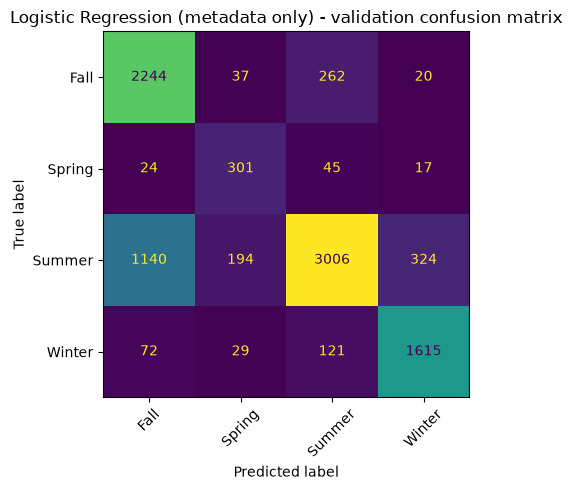

Saved metadata-only baseline to ../data/processed/task2_models


In [8]:
# Metadata-only baseline: how far do tabular features alone get us on season prediction,
# before we spend effort on the image branch at all?
BASELINE_DIR = OUT_DIR / 'task2_models'
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

FINAL_META_FEATURES = ['gender', 'articleType', 'usage', 'year']
META_CAT_FINAL = [c for c in FINAL_META_FEATURES if c != 'year']
META_NUM_FINAL = ['year']
meta_preprocessor_final = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), META_CAT_FINAL),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), META_NUM_FINAL)
])


X_train_final = task2_train[FINAL_META_FEATURES].copy()
X_val_final = task2_val[FINAL_META_FEATURES].copy()
meta_train_final = meta_preprocessor_final.fit_transform(X_train_final).astype('float32')
meta_val_final = meta_preprocessor_final.transform(X_val_final).astype('float32')

print('Metadata train shape:', meta_train_final.shape)
print('Metadata validation shape:', meta_val_final.shape)
print('Encoded target shapes:', y_train.shape, y_val.shape)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logreg.fit(meta_train_final, y_train)

logreg_train_f1 = f1_score(y_train, logreg.predict(meta_train_final), average='macro')
logreg_val_pred = logreg.predict(meta_val_final)
logreg_val_f1 = f1_score(y_val, logreg_val_pred, average='macro')

print(f'Logistic Regression (metadata only) -- train F1: {logreg_train_f1:.4f}, val F1: {logreg_val_f1:.4f}\n')
print(classification_report(y_val, logreg_val_pred, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, logreg_val_pred, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('Logistic Regression (metadata only) - validation confusion matrix')
plt.tight_layout()
plt.show()

joblib.dump(logreg, BASELINE_DIR / 'logreg_metadata_baseline.joblib')
print(f'Saved metadata-only baseline to {BASELINE_DIR}')

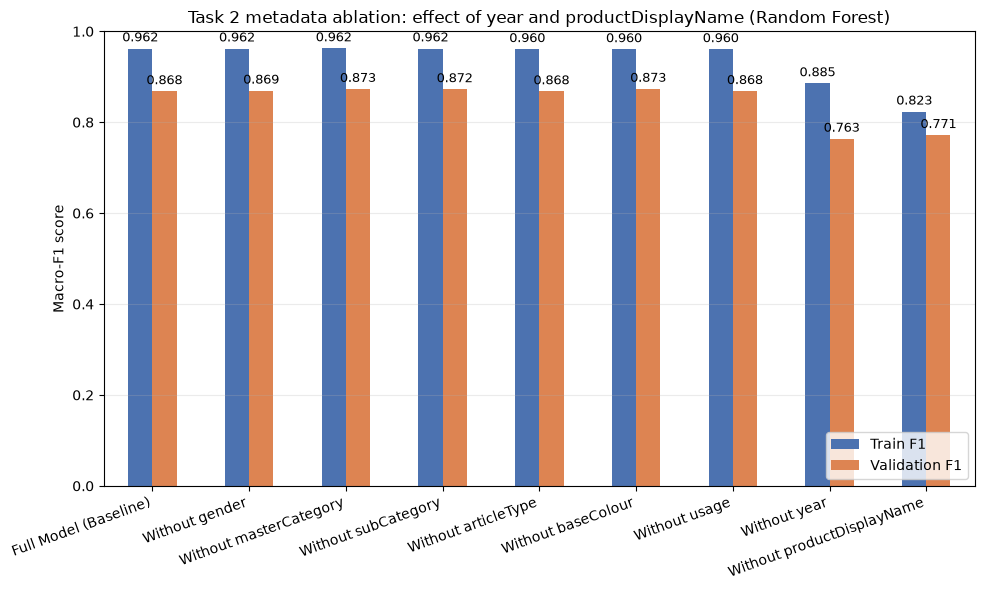

In [9]:
ax = ablation_df.plot(kind='bar', figsize=(10, 6), ylim=(0, 1), rot=20, color=['#4C72B0', '#DD8452'])
plt.ylabel('Macro-F1 score')
plt.title('Task 2 metadata ablation: effect of year and productDisplayName (Random Forest)')
plt.grid(axis='y', alpha=.25)
plt.xticks(ha='right')
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()


In [ ]:
import copy
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torchvision.models import resnet18, ResNet18_Weights, mobilenet_v3_small, MobileNet_V3_Small_Weights
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE, EPOCHS, NUM_WORKERS = 64, 70, 4

sampler = get_weighted_sampler(task2_train, 'season')

class EarlyStopping:
    """Stops training when a monitored score stops improving.
    mode='max' for metrics like macro-F1 (higher is better).
    mode='min' for metrics like validation loss (lower is better)."""
    def __init__(self, patience=5, delta=0, mode='max'):
        assert mode in ('max', 'min')
        self.patience = patience
        self.delta = delta
        self.mode = mode
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_state = None

    def __call__(self, value, model):
        score = value if self.mode == 'max' else -value
        if self.best_score is None or score > self.best_score + self.delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_state)
        return model

class MultiInputDataset(Dataset):
    def __init__(self, frame, metadata, labels, image_dir, transform):
        self.frame, self.metadata, self.labels = frame.reset_index(drop=True), metadata, labels
        self.image_dir, self.transform = image_dir, transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, i):
        with Image.open(self.image_dir / f"{self.frame.iloc[i]['id']}.jpg") as im:
            image = self.transform(im)
        return image, torch.tensor(self.metadata[i].toarray() if hasattr(self.metadata[i], 'toarray') else self.metadata[i], dtype=torch.float32).squeeze(0), torch.tensor(self.labels[i], dtype=torch.long)

# Build datasets and loaders for the multi-input model.
train_ds = MultiInputDataset(task2_train, meta_train_final, y_train, IMAGES_TRAIN_DIR, train_transform)
val_ds = MultiInputDataset(task2_val, meta_val_final, y_val, IMAGES_TRAIN_DIR, eval_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS,
                           persistent_workers=(NUM_WORKERS > 0))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                         persistent_workers=(NUM_WORKERS > 0))

# Shared loaders for the two image-only comparison models 
train_ds_img = FashionImageDataset(task2_train, IMAGES_TRAIN_DIR, 'season_enc', train_transform)
train_loader_img = DataLoader(train_ds_img, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS,
                            persistent_workers=(NUM_WORKERS > 0))
val_loader_img = DataLoader(FashionImageDataset(task2_val, IMAGES_TRAIN_DIR, 'season_enc', eval_transform),
                            batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                            persistent_workers=(NUM_WORKERS > 0))

# Create pretrained image-only comparison models and replace their classifiers for season prediction.
def make_pretrained(model_name):
    if model_name == 'resnet18':
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, len(season_encoder.classes_))
    else:
        model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, len(season_encoder.classes_))
    return model.to(DEVICE)

class PretrainedResNet18Encoder(nn.Module):
    """ImageNet-pretrained ResNet18 as a feature extractor for MultiInputNet --
    the missing cell of the 2x2 grid: pretrained encoder WITH metadata."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim = out_dim
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))

class SmallImageEncoder(nn.Module):
    """From-scratch CNN sized for 60x80 images - no aggressive early downsampling."""
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 60x80 -> 30x40

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                    # 30x40 -> 15x20

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.out_dim = out_dim
        self.proj = nn.Linear(128, out_dim)

    def forward(self, x):
        return self.proj(self.features(x).flatten(1))

class ResNet18Encoder(nn.Module):
    """From-scratch ResNet18 backbone, weights=None - kept as a comparison point
    against SmallImageEncoder to show whether stem downsampling hurts at 60x80."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=None)
        self.out_dim = out_dim
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))



class ConvBlock(nn.Module):
    """Residual Conv Block with SiLU and BatchNorm."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut matching if channels change
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + residual)


class ImprovedSmallImageEncoder(nn.Module):
    """Upgraded small CNN with residual connections, SiLU activations, 
    and gradual spatial downsampling for 60x80 images."""
    def __init__(self, out_dim=128, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        
        self.stage1 = ConvBlock(3, 32)
        self.pool1  = nn.MaxPool2d(2)                            # 60x80 -> 30x40
        
        self.stage2 = ConvBlock(32, 64)
        self.pool2  = nn.MaxPool2d(2)                            # 30x40 -> 15x20
        
        self.stage3 = ConvBlock(64, 128)
        self.pool3  = nn.MaxPool2d(2)                            # 15x20 -> 7x10
        
        self.stage4 = ConvBlock(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)               # 7x10  -> 1x1
        
        self.proj = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.SiLU()
        )

    def forward(self, x):
        x = self.pool1(self.stage1(x))
        x = self.pool2(self.stage2(x))
        x = self.pool3(self.stage3(x))
        x = self.stage4(x)
        
        x = self.global_pool(x).flatten(1)
        return self.proj(x)

class SqueezeExcite(nn.Module):
    """Channel attention: pool each feature map to one number, learn a per-channel
    gate from those numbers, then rescale. Lets the network decide which feature
    maps matter for a given image rather than weighting all of them equally."""

    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

    def forward(self, x):
        s = x.mean(dim=(2, 3))                       # global average pool -> (B, C)
        s = torch.sigmoid(self.fc2(F.silu(self.fc1(s))))
        return x * s[:, :, None, None]


class SEResidualBlock(nn.Module):
    """Pre-activation residual block: BN -> SiLU -> conv, twice, plus a
    squeeze-excite gate and a skip connection. Pre-activation keeps the skip path
    a clean identity, which trains more stably at depth than the post-activation
    ordering used by the earlier blocks in this notebook."""

    def __init__(self, in_ch, out_ch, stride=1, drop=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.se = SqueezeExcite(out_ch)
        self.drop = nn.Dropout2d(drop) if drop > 0 else nn.Identity()
        self.shortcut = (nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
                         if (stride != 1 or in_ch != out_ch) else nn.Identity())

    def forward(self, x):
        out = F.silu(self.bn1(x))
        shortcut = self.shortcut(out if not isinstance(self.shortcut, nn.Identity) else x)
        out = self.conv1(out)
        out = self.conv2(F.silu(self.bn2(out)))
        out = self.se(self.drop(out))
        return out + shortcut


class SEResidualEncoder(nn.Module):
    """From-scratch SE-residual encoder sized for 60x80 inputs.
    Stages 32 -> 64 -> 128 -> 256, two blocks each, downsampling only between
    stages: 80x60 -> 40x30 -> 20x15 -> 10x8. Unlike ResNet18Encoder there is no
    stride-2 stem or stem max-pool, so no spatial detail is discarded up front."""

    def __init__(self, out_dim=128, widths=(32, 64, 128, 256), drop=0.1):
        super().__init__()
        self.stem = nn.Conv2d(3, widths[0], 3, padding=1, bias=False)
        stages = []
        in_ch = widths[0]
        for stage_idx, width in enumerate(widths):
            stride = 1 if stage_idx == 0 else 2
            stages.append(SEResidualBlock(in_ch, width, stride=stride, drop=drop))
            stages.append(SEResidualBlock(width, width, stride=1, drop=drop))
            in_ch = width
        self.stages = nn.Sequential(*stages)
        self.norm = nn.BatchNorm2d(in_ch)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
        self.proj = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_ch, out_dim))

    def forward(self, x):
        x = self.stages(self.stem(x))
        x = self.pool(F.silu(self.norm(x))).flatten(1)
        return self.proj(x)


class MultiInputNet(nn.Module):
    def __init__(self, metadata_dim, n_classes, image_encoder):
        super().__init__()
        self.image = image_encoder
        image_dim = image_encoder.out_dim
        self.meta_scale = nn.Parameter(torch.tensor(1.0))
        self.meta = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.head = nn.Sequential(
            nn.Linear(image_dim + 128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )
        
    def forward(self, image, metadata):
        img_feats = self.image(image)
        meta_feats = self.meta(metadata) * self.meta_scale
        fused = torch.cat([img_feats, meta_feats], dim=1)
        return self.head(fused)

In [11]:
def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].plot(history['train_loss'], label='Train loss')
    axes[0].plot(history['val_loss'], label='Val loss')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history['train_f1'], label='Train macro-F1')
    axes[1].plot(history['val_f1'], label='Val macro-F1')
    axes[1].set_title('Macro-F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def to_device(batch):
    """Both loaders end with the label; everything before it is model input.
    (image, label) -> inputs=[image]. (image, metadata, label) -> inputs=[image, metadata].
    This one line is what lets train_model and train_image_only collapse into one function."""
    *inputs, labels = batch
    return [x.to(DEVICE) for x in inputs], labels.to(DEVICE)


def run_epoch(model, loader, criterion, optimiser=None, desc=''):
    """One pass over `loader`. Training if `optimiser` is given, eval-only otherwise."""
    train_mode = optimiser is not None
    model.train() if train_mode else model.eval()

    running_loss, n, preds, actual = 0.0, 0, [], []
    with torch.set_grad_enabled(train_mode):
        for batch in tqdm(loader, desc=desc, leave=train_mode):
            inputs, labels = to_device(batch)
            logits = model(*inputs)
            loss = criterion(logits, labels)

            if train_mode:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()

            bs = labels.size(0)
            running_loss += loss.item() * bs
            n += bs
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            actual.extend(labels.cpu().numpy())

    return running_loss / n, f1_score(actual, preds, average='macro')


def fit(model, loader_tr, loader_va, model_name='model', patience=15, lr=3e-4, weight_decay=1e-4):
    """Replaces train_model and train_image_only. Same optimiser settings for every
    model (train_image_only used to skip weight_decay -- that was an accident of
    copy-paste, not a deliberate choice, so it's gone now)."""
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    early_stopping = EarlyStopping(patience=patience, delta=0.0, mode='min')
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = None
    best_val_loss = None
    best_epoch = None

    for epoch in range(EPOCHS):
        tag = f'{model_name} {epoch + 1}/{EPOCHS}'
        train_loss, train_f1 = run_epoch(model, loader_tr, criterion, optimiser, desc=f'{tag} train')
        val_loss, val_f1 = run_epoch(model, loader_va, criterion, None, desc=f'{tag} val')

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1); history['val_f1'].append(val_f1)
        current_lr = optimiser.param_groups[0]['lr']
        print(f'Epoch {epoch + 1}/{EPOCHS} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - '
              f'train_f1: {train_f1:.4f} - val_f1: {val_f1:.4f} - lr: {current_lr:.2e}')

        scheduler.step(val_loss)
        early_stopping(val_loss, model)
        if early_stopping.counter == 0:
            best_val_f1 = val_f1
            best_val_loss = val_loss
            best_epoch = epoch + 1
        if early_stopping.early_stop:
            print(f'Early stopping triggered at epoch {epoch + 1} (best epoch was {best_epoch})')
            break

    model = early_stopping.load_best_model(model)
    plot_training_curves(history, model_name)

    print(f'>>> Best checkpoint for {model_name}: epoch {best_epoch}  '
          f'(val_loss={best_val_loss:.4f}, val_f1={best_val_f1:.4f})')

    return model, best_val_f1, best_epoch


def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_actual = []
    
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            
            # Keep predictions and labels on GPU as tensors
            preds = model(*inputs).argmax(dim=1)
            
            all_preds.append(preds)
            all_actual.append(labels)
            
    # Concatenate directly on GPU, then transfer to CPU ONCE
    preds_np = torch.cat(all_preds).cpu().numpy()
    actual_np = torch.cat(all_actual).cpu().numpy()
    
    return f1_score(actual_np, preds_np, average='macro')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 219MB/s]


ResNet18 (pretrained) 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet18 (pretrained) 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9392 - val_loss: 1.0612 - train_f1: 0.6620 - val_f1: 0.5556 - lr: 3.00e-04


...

ResNet18 (pretrained) 26/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 26/70 - train_loss: 0.4001 - val_loss: 0.8541 - train_f1: 0.9751 - val_f1: 0.7709 - lr: 9.37e-06


ResNet18 (pretrained) 27/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

ResNet18 (pretrained) 27/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 27/70 - train_loss: 0.4000 - val_loss: 0.8581 - train_f1: 0.9753 - val_f1: 0.7698 - lr: 9.37e-06
Early stopping triggered at epoch 27 (best epoch was 12)


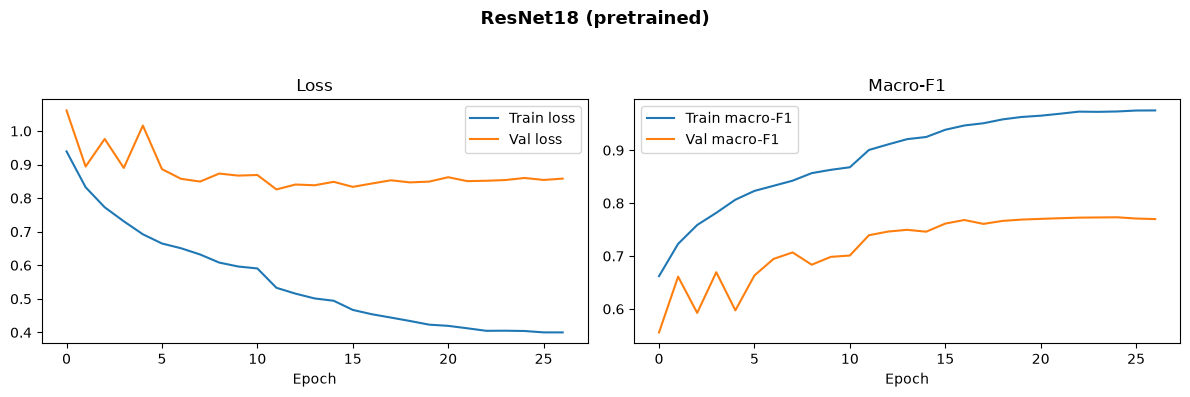

>>> Best checkpoint for ResNet18 (pretrained): epoch 12  (val_loss=0.8259, val_f1=0.7394)


In [12]:
OUTPUT_DIR = Path('../outputs') / 'task2_models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(RANDOM_STATE)
results = {}
resnet_model, resnet_f1, resnet_epoch = fit(
    make_pretrained('resnet18'), train_loader_img, val_loader_img, model_name='ResNet18 (pretrained)')
results['ResNet18 (pretrained)'] = (resnet_f1, resnet_epoch)

ResNet18 (pretrained, image only) -- train F1: 0.9046, val F1: 0.7394

              precision    recall  f1-score   support

        Fall       0.67      0.73      0.70      2563
      Spring       0.72      0.73      0.73       387
      Summer       0.81      0.74      0.77      4664
      Winter       0.73      0.79      0.76      1837

    accuracy                           0.75      9451
   macro avg       0.73      0.75      0.74      9451
weighted avg       0.75      0.75      0.75      9451



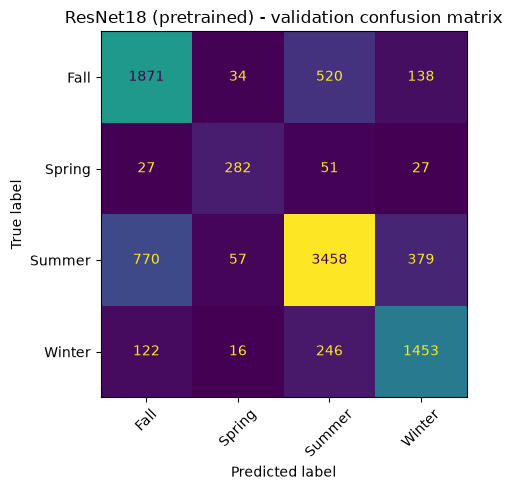

In [13]:
# Testing: ResNet18 (pretrained, image-only) -- same treatment as the metadata-only
# baseline above (val F1, classification report, confusion matrix), so both baselines
# are fully tested here before we move on to the multi-input models.
image_train_loader = DataLoader(
    FashionImageDataset(task2_train, IMAGES_TRAIN_DIR, 'season_enc', eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
image_val_loader = DataLoader(
    FashionImageDataset(task2_val, IMAGES_TRAIN_DIR, 'season_enc', eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

resnet_train_f1 = evaluate(resnet_model, image_train_loader)

resnet_model.eval()
resnet_val_preds = []
with torch.no_grad():
    for images, labels in image_val_loader:
        images = images.to(DEVICE)
        preds = resnet_model(images).argmax(dim=1).cpu().numpy()
        resnet_val_preds.extend(preds)
resnet_val_preds = np.array(resnet_val_preds)
resnet_val_f1 = f1_score(y_val, resnet_val_preds, average='macro')

print(f'ResNet18 (pretrained, image only) -- train F1: {resnet_train_f1:.4f}, val F1: {resnet_val_f1:.4f}\n')
print(classification_report(y_val, resnet_val_preds, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, resnet_val_preds, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('ResNet18 (pretrained) - validation confusion matrix')
plt.tight_layout()
plt.show()


#### 1c. ImprovedSmallCNN (image-only)

`styles_prediction.csv` (the real test set) has no metadata at all, so the multi-input model can't run on it directly -- `MultiInputNet` requires both an image and a metadata vector. This image-only version of our chosen encoder (`ImprovedSmallImageEncoder`) is what we actually use for test-set predictions. It's trained and tested here, alongside the other image-only/metadata-only baselines, before the multi-input section.

ImprovedSmallCNN (image-only) 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

ImprovedSmallCNN (image-only) 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 1.0490 - val_loss: 1.1014 - train_f1: 0.5732 - val_f1: 0.5348 - lr: 3.00e-04


ImprovedSmallCNN (image-only) 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

ImprovedSmallCNN (image-only) 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

ImprovedSmallCNN (image-only) 39/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 39/70 - train_loss: 0.5554 - val_loss: 0.8434 - train_f1: 0.8991 - val_f1: 0.7312 - lr: 2.34e-06


ImprovedSmallCNN (image-only) 40/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

ImprovedSmallCNN (image-only) 40/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 40/70 - train_loss: 0.5534 - val_loss: 0.8375 - train_f1: 0.8980 - val_f1: 0.7364 - lr: 2.34e-06
Early stopping triggered at epoch 40 (best epoch was 25)


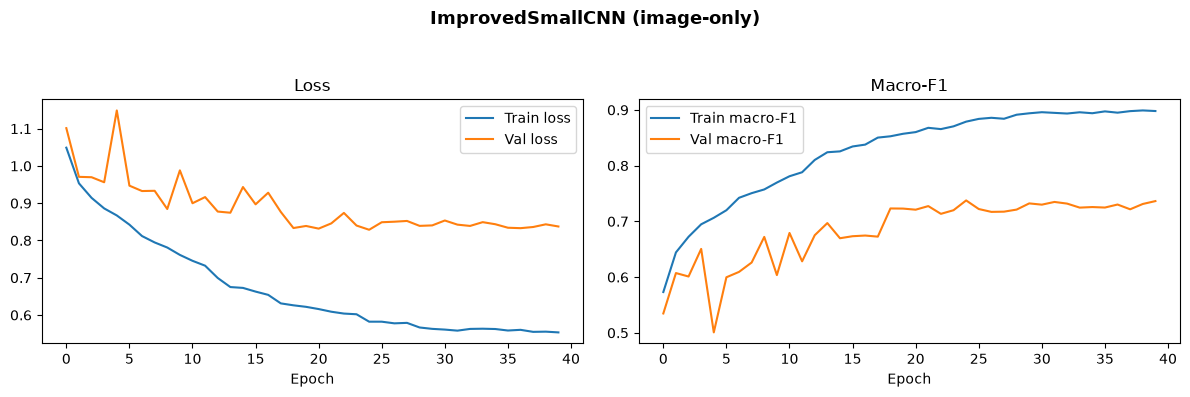

>>> Best checkpoint for ImprovedSmallCNN (image-only): epoch 25  (val_loss=0.8287, val_f1=0.7376)


In [14]:
class ImageOnlyClassifier(nn.Module):
    """An encoder plus a plain linear head -- no metadata branch. Used to get a
    working model for images with no metadata, e.g. the real test set."""
    def __init__(self, encoder, n_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(encoder.out_dim, n_classes)

    def forward(self, x):
        return self.head(self.encoder(x))


torch.manual_seed(RANDOM_STATE)
improved_small_cnn_img_only_model, improved_small_cnn_img_only_f1, improved_small_cnn_img_only_epoch = fit(
    ImageOnlyClassifier(ImprovedSmallImageEncoder(out_dim=128), len(season_encoder.classes_)).to(DEVICE),
    train_loader_img, val_loader_img, model_name='ImprovedSmallCNN (image-only)')
results['ImprovedSmallCNN (image-only)'] = (improved_small_cnn_img_only_f1, improved_small_cnn_img_only_epoch)


ImprovedSmallCNN (image only) -- train F1: 0.8895, val F1: 0.7376

              precision    recall  f1-score   support

        Fall       0.67      0.75      0.71      2563
      Spring       0.77      0.68      0.72       387
      Summer       0.79      0.76      0.78      4664
      Winter       0.76      0.72      0.74      1837

    accuracy                           0.75      9451
   macro avg       0.75      0.73      0.74      9451
weighted avg       0.75      0.75      0.75      9451



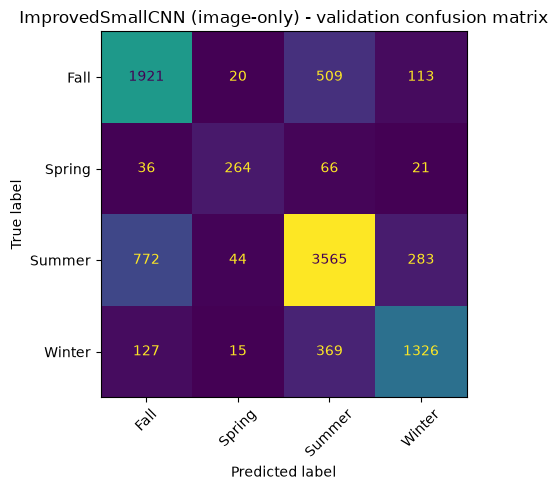

Saved ImprovedSmallCNN (image-only) to ../outputs/task2_models/improved_small_cnn_image_only.pt


In [15]:
# Testing: ImprovedSmallCNN (image-only) -- same treatment as the other baselines above.
improved_small_cnn_img_only_train_f1 = evaluate(improved_small_cnn_img_only_model, image_train_loader)

improved_small_cnn_img_only_model.eval()
improved_img_only_val_preds = []
with torch.no_grad():
    for images, labels in image_val_loader:
        images = images.to(DEVICE)
        preds = improved_small_cnn_img_only_model(images).argmax(dim=1).cpu().numpy()
        improved_img_only_val_preds.extend(preds)
improved_img_only_val_preds = np.array(improved_img_only_val_preds)
improved_small_cnn_img_only_val_f1 = f1_score(y_val, improved_img_only_val_preds, average='macro')

print(f'ImprovedSmallCNN (image only) -- train F1: {improved_small_cnn_img_only_train_f1:.4f}, '
      f'val F1: {improved_small_cnn_img_only_val_f1:.4f}\n')
print(classification_report(y_val, improved_img_only_val_preds, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, improved_img_only_val_preds, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('ImprovedSmallCNN (image-only) - validation confusion matrix')
plt.tight_layout()
plt.show()

# Saved separately since this (not the multi-input model) is what's actually used for
# the metadata-free test set.
torch.save({
    'model_state_dict': improved_small_cnn_img_only_model.state_dict(),
    'n_classes': len(season_encoder.classes_),
    'out_dim': 128,
    'val_f1': improved_small_cnn_img_only_val_f1,
}, OUTPUT_DIR / 'improved_small_cnn_image_only.pt')
print(f'Saved ImprovedSmallCNN (image-only) to {OUTPUT_DIR / "improved_small_cnn_image_only.pt"}')


#### 1d. SmallCNN image-only

SmallCNN (image-only) 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

SmallCNN (image-only) 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 1.1379 - val_loss: 1.0600 - train_f1: 0.5078 - val_f1: 0.5257 - lr: 3.00e-04


SmallCNN (image-only) 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

SmallCNN (image-only) 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

SmallCNN (image-only) 37/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 37/70 - train_loss: 0.7781 - val_loss: 0.9387 - train_f1: 0.7692 - val_f1: 0.6360 - lr: 5.86e-07


SmallCNN (image-only) 38/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

SmallCNN (image-only) 38/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 38/70 - train_loss: 0.7731 - val_loss: 0.9275 - train_f1: 0.7717 - val_f1: 0.6372 - lr: 5.86e-07
Early stopping triggered at epoch 38 (best epoch was 23)


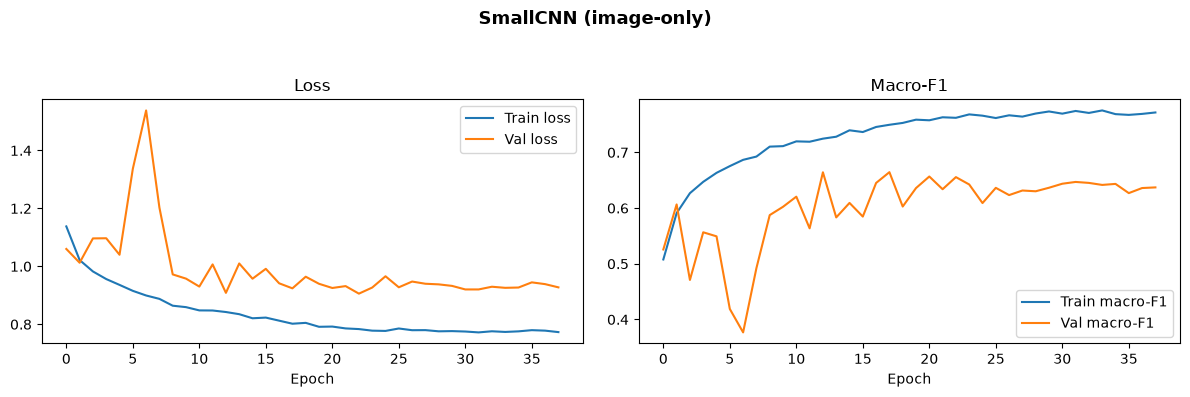

>>> Best checkpoint for SmallCNN (image-only): epoch 23  (val_loss=0.9058, val_f1=0.6556)


In [16]:
torch.manual_seed(RANDOM_STATE)
small_cnn_img_only_model, small_cnn_img_only_f1, small_cnn_img_only_epoch = fit(
    ImageOnlyClassifier(SmallImageEncoder(out_dim=128), len(season_encoder.classes_)).to(DEVICE),
    train_loader_img, val_loader_img, model_name='SmallCNN (image-only)')
results['SmallCNN (image-only)'] = (small_cnn_img_only_f1, small_cnn_img_only_epoch)

SmallCNN (image only) -- train F1: 0.7266, val F1: 0.6556

              precision    recall  f1-score   support

        Fall       0.63      0.67      0.65      2563
      Spring       0.44      0.73      0.55       387
      Summer       0.77      0.66      0.71      4664
      Winter       0.67      0.75      0.70      1837

    accuracy                           0.69      9451
   macro avg       0.63      0.70      0.66      9451
weighted avg       0.70      0.69      0.69      9451



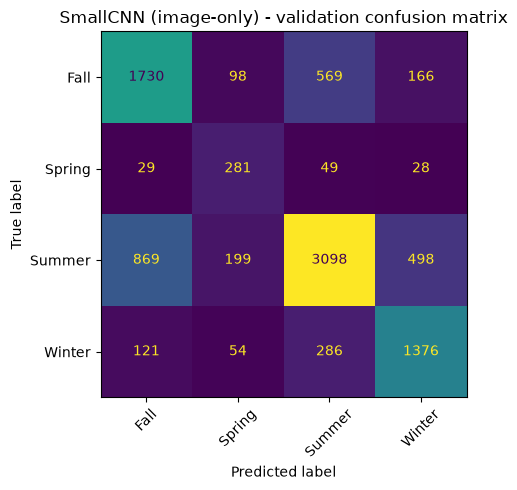

Saved SmallCNN (image-only) to ../outputs/task2_models/small_cnn_image_only.pt


In [17]:
# Testing: SmallCNN (image-only) -- same treatment as the other baselines above.
small_cnn_img_only_train_f1 = evaluate(small_cnn_img_only_model, image_train_loader)

small_cnn_img_only_model.eval()
small_cnn_img_only_val_preds = []
with torch.no_grad():
    for images, labels in image_val_loader:
        images = images.to(DEVICE)
        preds = small_cnn_img_only_model(images).argmax(dim=1).cpu().numpy()
        small_cnn_img_only_val_preds.extend(preds)
small_cnn_img_only_val_preds = np.array(small_cnn_img_only_val_preds)
small_cnn_img_only_val_f1 = f1_score(y_val, small_cnn_img_only_val_preds, average='macro')

print(f'SmallCNN (image only) -- train F1: {small_cnn_img_only_train_f1:.4f}, '
      f'val F1: {small_cnn_img_only_val_f1:.4f}\n')
print(classification_report(y_val, small_cnn_img_only_val_preds, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, small_cnn_img_only_val_preds, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('SmallCNN (image-only) - validation confusion matrix')
plt.tight_layout()
plt.show()

torch.save({
    'model_state_dict': small_cnn_img_only_model.state_dict(),
    'n_classes': len(season_encoder.classes_),
    'out_dim': 128,
    'val_f1': small_cnn_img_only_val_f1,
}, OUTPUT_DIR / 'small_cnn_image_only.pt')
print(f'Saved SmallCNN (image-only) to {OUTPUT_DIR / "small_cnn_image_only.pt"}')

#### 1e. SEResidual (image-only)

SEResidual (image-only) 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

SEResidual (image-only) 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 1.1266 - val_loss: 1.0834 - train_f1: 0.5115 - val_f1: 0.5557 - lr: 3.00e-04


SEResidual (image-only) 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

SEResidual (image-only) 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

SEResidual (image-only) 48/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 48/70 - train_loss: 0.6113 - val_loss: 0.8430 - train_f1: 0.8559 - val_f1: 0.7200 - lr: 5.86e-07


SEResidual (image-only) 49/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

SEResidual (image-only) 49/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 49/70 - train_loss: 0.6044 - val_loss: 0.8482 - train_f1: 0.8583 - val_f1: 0.7153 - lr: 5.86e-07
Early stopping triggered at epoch 49 (best epoch was 34)


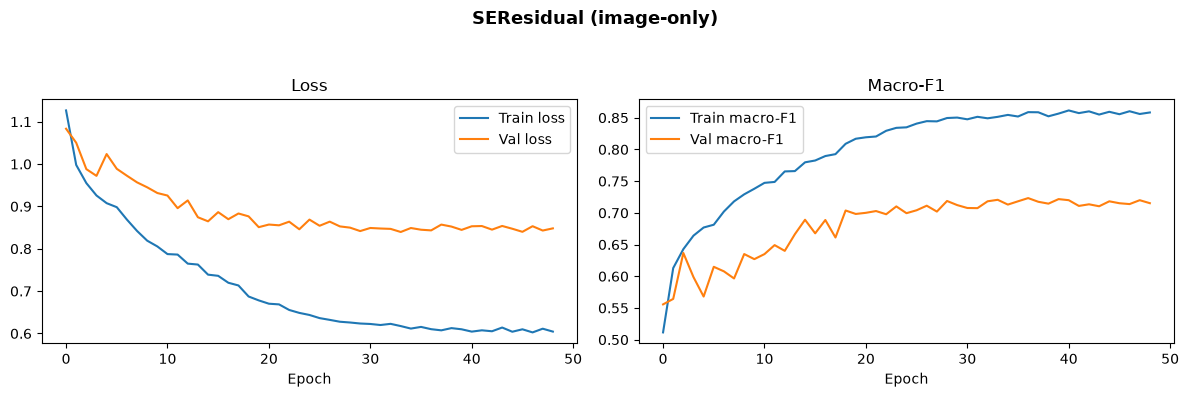

>>> Best checkpoint for SEResidual (image-only): epoch 34  (val_loss=0.8396, val_f1=0.7206)


In [18]:
torch.manual_seed(RANDOM_STATE)
seres_img_only_model, seres_img_only_f1, seres_img_only_epoch = fit(
    ImageOnlyClassifier(SEResidualEncoder(out_dim=128), len(season_encoder.classes_)).to(DEVICE),
    train_loader_img, val_loader_img, model_name='SEResidual (image-only)')
results['SEResidual (image-only)'] = (seres_img_only_f1, seres_img_only_epoch)

SEResidual (image only) -- train F1: 0.8612, val F1: 0.7206

              precision    recall  f1-score   support

        Fall       0.69      0.68      0.69      2563
      Spring       0.73      0.70      0.71       387
      Summer       0.79      0.73      0.76      4664
      Winter       0.65      0.81      0.72      1837

    accuracy                           0.73      9451
   macro avg       0.72      0.73      0.72      9451
weighted avg       0.74      0.73      0.73      9451



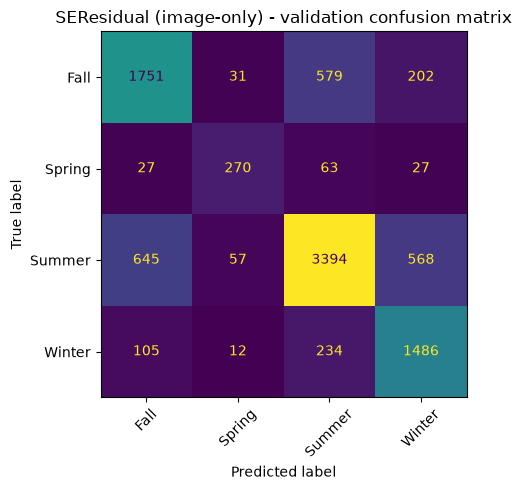

Saved SEResidual (image-only) to ../outputs/task2_models/seres_image_only.pt


In [19]:
# Testing: SEResidual (image-only) -- same treatment as the other baselines above.
seres_img_only_train_f1 = evaluate(seres_img_only_model, image_train_loader)

seres_img_only_model.eval()
seres_img_only_val_preds = []
with torch.no_grad():
    for images, labels in image_val_loader:
        images = images.to(DEVICE)
        preds = seres_img_only_model(images).argmax(dim=1).cpu().numpy()
        seres_img_only_val_preds.extend(preds)
seres_img_only_val_preds = np.array(seres_img_only_val_preds)
seres_img_only_val_f1 = f1_score(y_val, seres_img_only_val_preds, average='macro')

print(f'SEResidual (image only) -- train F1: {seres_img_only_train_f1:.4f}, '
      f'val F1: {seres_img_only_val_f1:.4f}\n')
print(classification_report(y_val, seres_img_only_val_preds, target_names=season_encoder.classes_))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, seres_img_only_val_preds, display_labels=season_encoder.classes_,
    ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title('SEResidual (image-only) - validation confusion matrix')
plt.tight_layout()
plt.show()

torch.save({
    'model_state_dict': seres_img_only_model.state_dict(),
    'n_classes': len(season_encoder.classes_),
    'out_dim': 128,
    'val_f1': seres_img_only_val_f1,
}, OUTPUT_DIR / 'seres_image_only.pt')
print(f'Saved SEResidual (image-only) to {OUTPUT_DIR / "seres_image_only.pt"}')

#### 2. Multi-input model training

Before training multi-input model, we performed a check to see among 4 types of fusion: concat, gated, sum, film which one is the best option in this task. 

Fusion-concat 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

Fusion-concat 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9365 - val_loss: 0.9690 - train_f1: 0.6544 - val_f1: 0.6793 - lr: 3.00e-04


Fusion-concat 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

Fusion-concat 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

Fusion-concat 23/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 23/70 - train_loss: 0.5559 - val_loss: 0.8111 - train_f1: 0.9021 - val_f1: 0.8167 - lr: 1.87e-05


Fusion-concat 24/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

Fusion-concat 24/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 24/70 - train_loss: 0.5509 - val_loss: 0.8179 - train_f1: 0.9062 - val_f1: 0.8226 - lr: 1.87e-05
Early stopping triggered at epoch 24 (best epoch was 16)


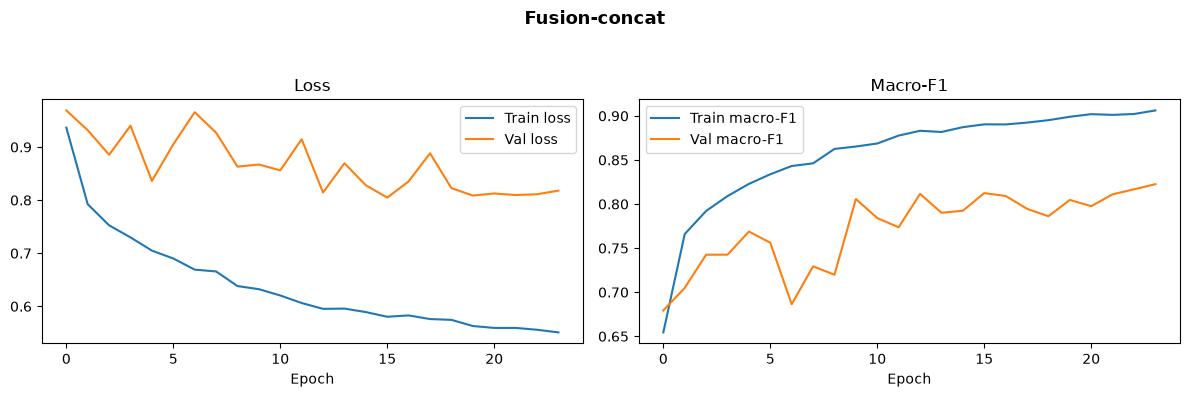

>>> Best checkpoint for Fusion-concat: epoch 16  (val_loss=0.8048, val_f1=0.8124)


Fusion-sum 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

Fusion-sum 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9520 - val_loss: 0.9356 - train_f1: 0.6455 - val_f1: 0.6749 - lr: 3.00e-04


Fusion-sum 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Fusion-sum 17/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 17/70 - train_loss: 0.5691 - val_loss: 0.8073 - train_f1: 0.8973 - val_f1: 0.8152 - lr: 3.75e-05


Fusion-sum 18/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

Fusion-sum 18/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 18/70 - train_loss: 0.5669 - val_loss: 0.8138 - train_f1: 0.8975 - val_f1: 0.7947 - lr: 3.75e-05
Early stopping triggered at epoch 18 (best epoch was 10)


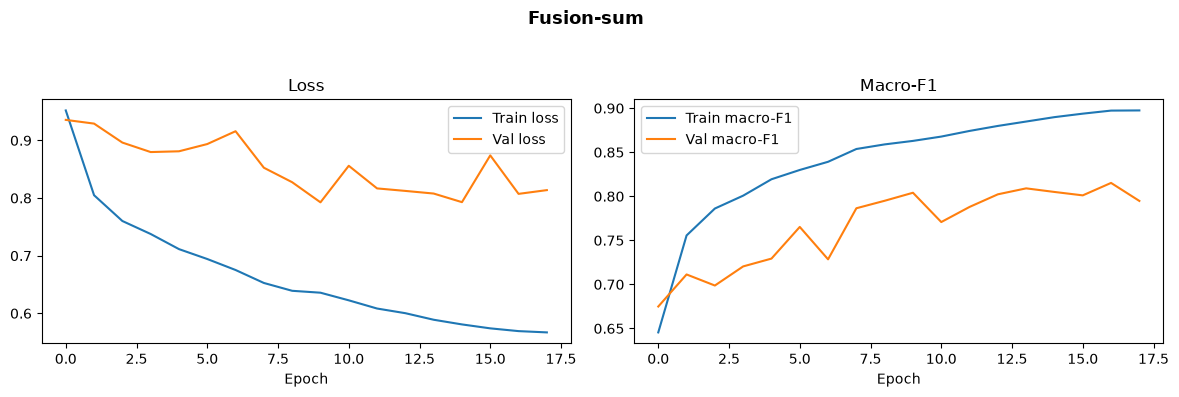

>>> Best checkpoint for Fusion-sum: epoch 10  (val_loss=0.7926, val_f1=0.8040)


Fusion-gated 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

Fusion-gated 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9493 - val_loss: 0.9475 - train_f1: 0.6497 - val_f1: 0.6721 - lr: 3.00e-04


Fusion-gated 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Fusion-gated 25/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 25/70 - train_loss: 0.5583 - val_loss: 0.8968 - train_f1: 0.9025 - val_f1: 0.8155 - lr: 1.87e-05


Fusion-gated 26/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

Fusion-gated 26/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 26/70 - train_loss: 0.5506 - val_loss: 0.8601 - train_f1: 0.9076 - val_f1: 0.8025 - lr: 1.87e-05
Early stopping triggered at epoch 26 (best epoch was 18)


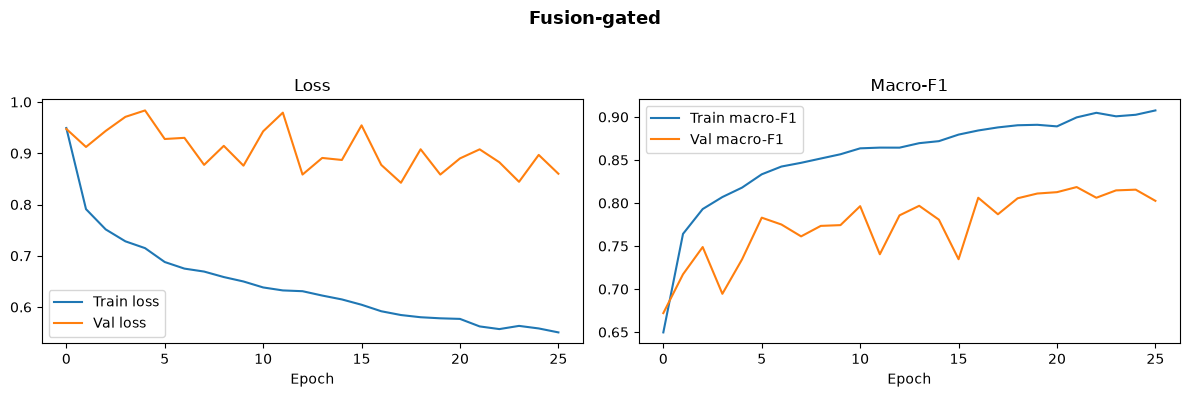

>>> Best checkpoint for Fusion-gated: epoch 18  (val_loss=0.8424, val_f1=0.7869)


Fusion-film 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

Fusion-film 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9260 - val_loss: 1.0053 - train_f1: 0.6657 - val_f1: 0.6530 - lr: 3.00e-04


Fusion-film 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

Fusion-film 11/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 11/70 - train_loss: 0.6042 - val_loss: 0.9498 - train_f1: 0.8789 - val_f1: 0.7761 - lr: 7.50e-05


Fusion-film 12/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

Fusion-film 12/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 12/70 - train_loss: 0.6031 - val_loss: 0.9954 - train_f1: 0.8786 - val_f1: 0.7710 - lr: 7.50e-05
Early stopping triggered at epoch 12 (best epoch was 4)


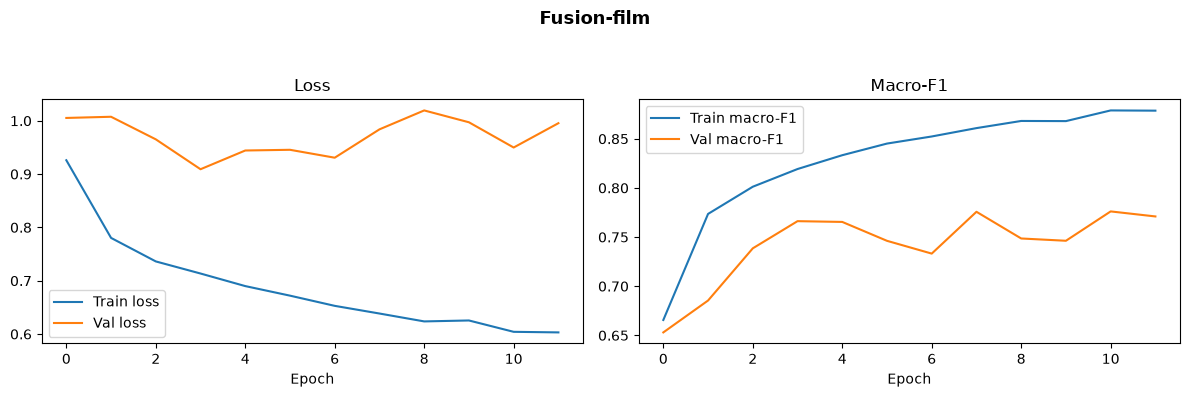

>>> Best checkpoint for Fusion-film: epoch 4  (val_loss=0.9091, val_f1=0.7662)
concat    0.812404
sum       0.804027
gated     0.786926
film      0.766203
Name: Validation macro-F1, dtype: float64


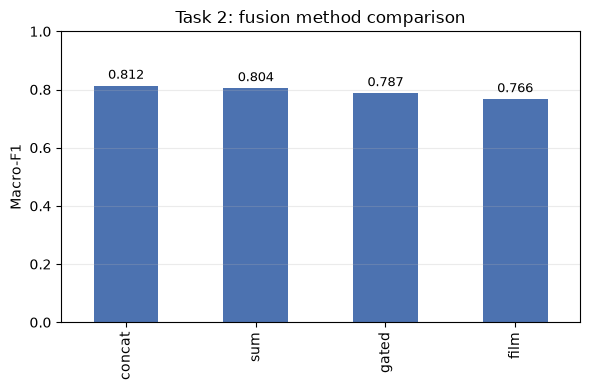

Best fusion method: concat (val macro-F1 = 0.8124)


In [20]:
# ---- Fusion-method ablation: which way of combining image + metadata features is best? ----
import torch.nn.functional as F

class FusionMultiInputNet(nn.Module):
    """Same idea as MultiInputNet, but the fusion step is swappable so we can
    isolate the effect of *how* image and metadata features are combined,
    keeping the image encoder and metadata branch identical across runs.

    fusion:
      - 'concat' : baseline used elsewhere in the notebook -> [img_feats, meta_feats]
      - 'sum'    : project both branches to the same width and add them
      - 'gated'  : learn a per-sample gate g in [0,1] from both branches,
                   fused = g * img_feats + (1-g) * meta_feats
      - 'film'   : metadata predicts a per-channel scale/shift (gamma, beta)
                   that modulates the image features (FiLM-style conditioning)
    """
    def __init__(self, metadata_dim, n_classes, image_encoder, fusion='concat', hidden=128):
        super().__init__()
        assert fusion in ('concat', 'sum', 'gated', 'film')
        self.fusion = fusion
        self.image = image_encoder
        image_dim = image_encoder.out_dim

        self.meta = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        if fusion == 'concat':
            fused_dim = image_dim + hidden
        elif fusion == 'sum':
            self.img_proj = nn.Linear(image_dim, hidden)
            fused_dim = hidden
        elif fusion == 'gated':
            self.img_proj = nn.Linear(image_dim, hidden)
            self.gate = nn.Linear(image_dim + hidden, 1)
            fused_dim = hidden
        elif fusion == 'film':
            self.img_proj = nn.Linear(image_dim, hidden)
            self.film = nn.Linear(hidden, 2 * hidden)  # predicts (gamma, beta)
            fused_dim = hidden

        self.head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, image, metadata):
        img_feats = self.image(image)
        meta_feats = self.meta(metadata)

        if self.fusion == 'concat':
            fused = torch.cat([img_feats, meta_feats], dim=1)
        elif self.fusion == 'sum':
            fused = self.img_proj(img_feats) + meta_feats
        elif self.fusion == 'gated':
            img_p = self.img_proj(img_feats)
            g = torch.sigmoid(self.gate(torch.cat([img_feats, meta_feats], dim=1)))
            fused = g * img_p + (1 - g) * meta_feats
        elif self.fusion == 'film':
            img_p = self.img_proj(img_feats)
            gamma, beta = self.film(meta_feats).chunk(2, dim=1)
            fused = img_p * (1 + gamma) + beta

        return self.head(fused)


# Hold the image encoder fixed so the comparison isolates the fusion mechanism,
# not encoder capacity. Swap this for SEResidualEncoder if that ends up winning instead.
FUSION_ENCODER_CLS = ImprovedSmallImageEncoder
FUSION_METHODS = ['concat', 'sum', 'gated', 'film']

fusion_results = {}
fusion_models = {}

for fusion_type in FUSION_METHODS:
    torch.manual_seed(RANDOM_STATE)
    model = FusionMultiInputNet(
        metadata_dim=meta_train_final.shape[1],
        n_classes=len(season_encoder.classes_),
        image_encoder=FUSION_ENCODER_CLS(out_dim=128),
        fusion=fusion_type,
    ).to(DEVICE)

    # Use a smaller patience here (e.g. patience=5) if you just want a quick signal
    # rather than a fully-converged run for every fusion type.
    trained_model, val_f1, best_epoch = fit(
        model, train_loader, val_loader, model_name=f'Fusion-{fusion_type}', patience=8
    )
    fusion_results[fusion_type] = val_f1
    fusion_models[fusion_type] = trained_model

fusion_df = pd.Series(fusion_results, name='Validation macro-F1').sort_values(ascending=False)
print(fusion_df)

ax = fusion_df.plot(kind='bar', figsize=(6, 4), ylim=(0, 1), color='#4C72B0')
plt.ylabel('Macro-F1'); plt.title('Task 2: fusion method comparison'); plt.grid(axis='y', alpha=.25)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout(); plt.show()

best_fusion = fusion_df.idxmax()
print(f'Best fusion method: {best_fusion} (val macro-F1 = {fusion_df[best_fusion]:.4f})')

As seen with the result, concat is the best option at macro-F1 = 0.8124 so multi-input models will use this type of fusion.

It will also have a weight on the metadata prediction since through the testing with LogisticRegression baseline and image-only models, we found that LogisticRegression is more accurate in prediction using only metadata than other image-only models built from scratch. 

MultiInput-ResNet18Pretrained 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.8774 - val_loss: 0.8919 - train_f1: 0.7019 - val_f1: 0.7294 - lr: 3.00e-04


MultiInput-ResNet18Pretrained 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ResNet18Pretrained 47/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 47/70 - train_loss: 0.3799 - val_loss: 0.7862 - train_f1: 0.9910 - val_f1: 0.8285 - lr: 5.86e-07


MultiInput-ResNet18Pretrained 48/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained 48/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 48/70 - train_loss: 0.3803 - val_loss: 0.7897 - train_f1: 0.9910 - val_f1: 0.8295 - lr: 5.86e-07
Early stopping triggered at epoch 48 (best epoch was 33)


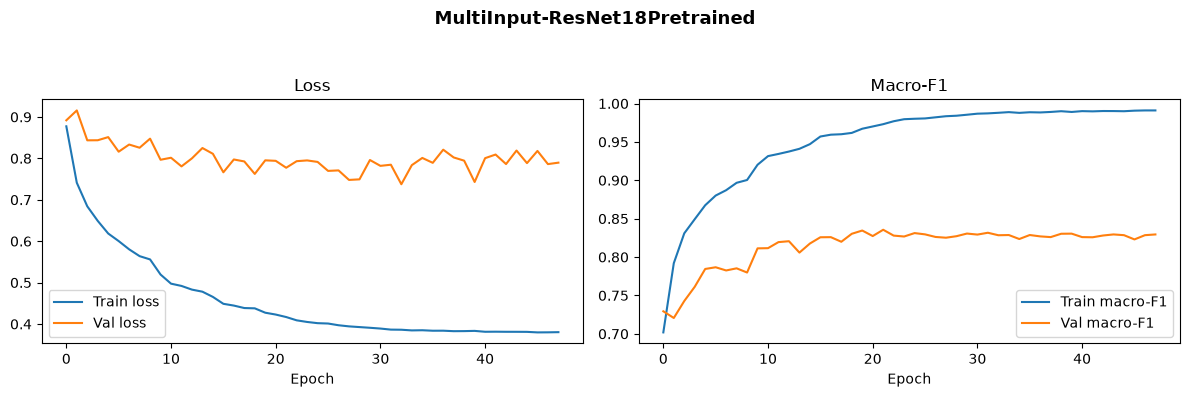

>>> Best checkpoint for MultiInput-ResNet18Pretrained: epoch 33  (val_loss=0.7375, val_f1=0.8284)


In [21]:
torch.manual_seed(RANDOM_STATE)
resnet_pretrained_model, resnet_pretrained_f1, resnet_pretrained_epoch = fit(
    MultiInputNet(meta_train_final.shape[1], len(season_encoder.classes_), PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader, val_loader, model_name='MultiInput-ResNet18Pretrained')
results['MultiInput-ResNet18Pretrained'] = (resnet_pretrained_f1, resnet_pretrained_epoch)


MultiInput-SmallCNN 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-SmallCNN 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9440 - val_loss: 0.9575 - train_f1: 0.6514 - val_f1: 0.6610 - lr: 3.00e-04


MultiInput-SmallCNN 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-SmallCNN 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-SmallCNN 36/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 36/70 - train_loss: 0.6061 - val_loss: 0.8221 - train_f1: 0.8796 - val_f1: 0.7739 - lr: 2.34e-06


MultiInput-SmallCNN 37/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-SmallCNN 37/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 37/70 - train_loss: 0.5956 - val_loss: 0.8098 - train_f1: 0.8840 - val_f1: 0.7842 - lr: 2.34e-06
Early stopping triggered at epoch 37 (best epoch was 22)


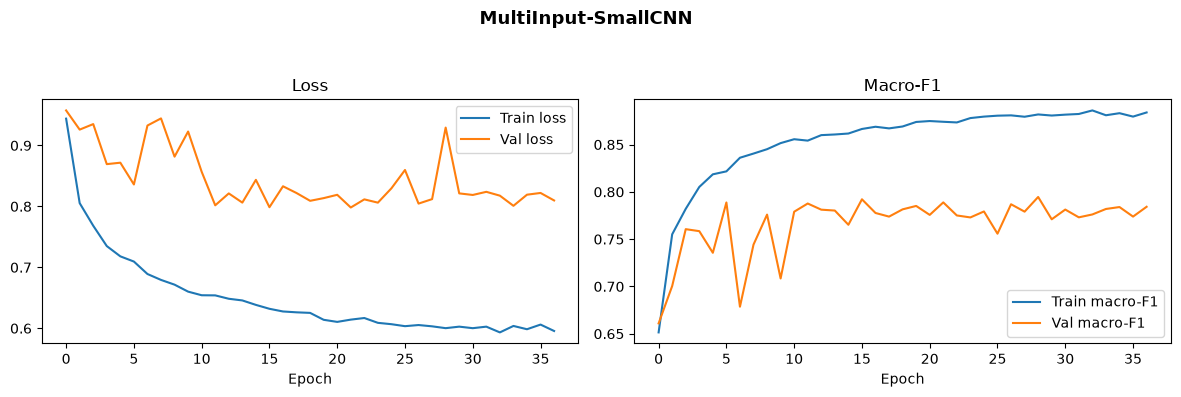

>>> Best checkpoint for MultiInput-SmallCNN: epoch 22  (val_loss=0.7982, val_f1=0.7889)


In [22]:
torch.manual_seed(RANDOM_STATE)
small_cnn_model, small_cnn_f1, small_cnn_epoch = fit(
    MultiInputNet(meta_train_final.shape[1], len(season_encoder.classes_), SmallImageEncoder(out_dim=128)).to(DEVICE), train_loader, val_loader,
    model_name='MultiInput-SmallCNN')
results['MultiInput-SmallCNN'] = (small_cnn_f1, small_cnn_epoch)

MultiInput-ResNet18Scratch 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ResNet18Scratch 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9181 - val_loss: 0.9699 - train_f1: 0.6645 - val_f1: 0.6612 - lr: 3.00e-04


MultiInput-ResNet18Scratch 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ResNet18Scratch 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ResNet18Scratch 47/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 47/70 - train_loss: 0.4200 - val_loss: 0.8191 - train_f1: 0.9723 - val_f1: 0.8223 - lr: 5.86e-07


MultiInput-ResNet18Scratch 48/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ResNet18Scratch 48/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 48/70 - train_loss: 0.4188 - val_loss: 0.8163 - train_f1: 0.9729 - val_f1: 0.8257 - lr: 5.86e-07
Early stopping triggered at epoch 48 (best epoch was 33)


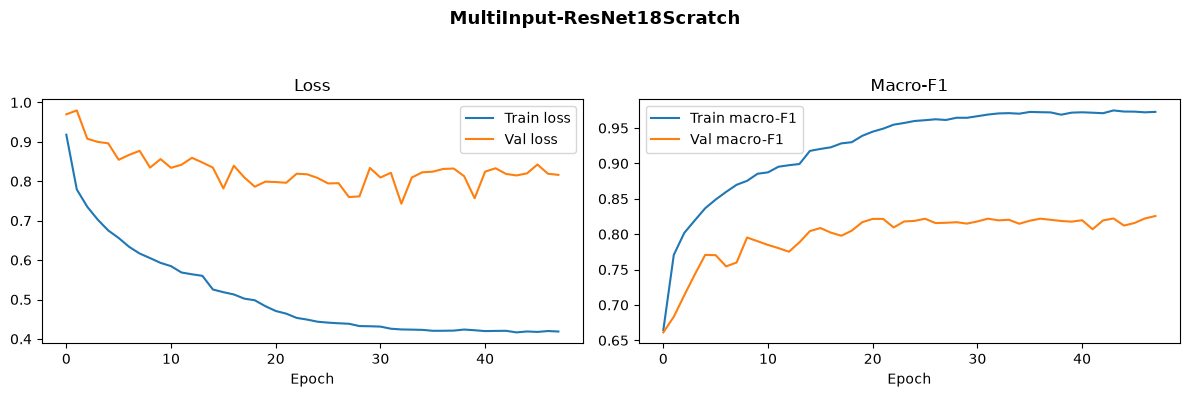

>>> Best checkpoint for MultiInput-ResNet18Scratch: epoch 33  (val_loss=0.7431, val_f1=0.8196)


In [23]:
torch.manual_seed(RANDOM_STATE)
resnet_scratch_model, resnet_scratch_f1, resnet_scratch_epoch = fit(
    MultiInputNet(meta_train_final.shape[1], len(season_encoder.classes_), ResNet18Encoder(out_dim=128)).to(DEVICE), train_loader, val_loader,
    model_name='MultiInput-ResNet18Scratch')
results['MultiInput-ResNet18Scratch'] = (resnet_scratch_f1, resnet_scratch_epoch)

MultiInput-ImprovedSmallCNN 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9352 - val_loss: 1.0061 - train_f1: 0.6534 - val_f1: 0.6513 - lr: 3.00e-04


MultiInput-ImprovedSmallCNN 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-ImprovedSmallCNN 36/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 36/70 - train_loss: 0.5667 - val_loss: 0.8356 - train_f1: 0.8993 - val_f1: 0.8145 - lr: 5.86e-07


MultiInput-ImprovedSmallCNN 37/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN 37/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 37/70 - train_loss: 0.5572 - val_loss: 0.8340 - train_f1: 0.9018 - val_f1: 0.8135 - lr: 5.86e-07
Early stopping triggered at epoch 37 (best epoch was 22)


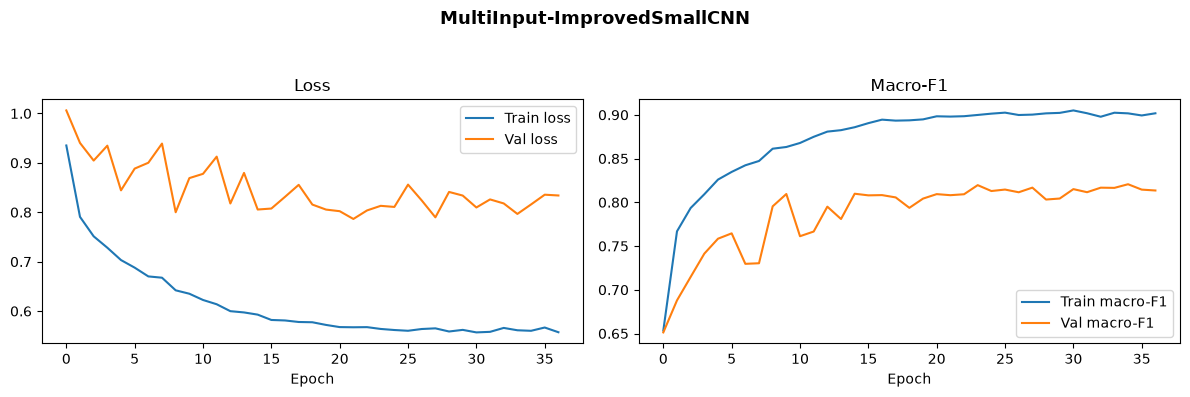

>>> Best checkpoint for MultiInput-ImprovedSmallCNN: epoch 22  (val_loss=0.7865, val_f1=0.8082)


In [24]:
torch.manual_seed(RANDOM_STATE)

improved_small_cnn_model, improved_small_cnn_f1, improved_small_cnn_epoch = fit(
    MultiInputNet(
        metadata_dim=meta_train_final.shape[1], 
        n_classes=len(season_encoder.classes_), 
        image_encoder=ImprovedSmallImageEncoder(out_dim=128)
    ).to(DEVICE), 
    train_loader, 
    val_loader,
    model_name='MultiInput-ImprovedSmallCNN'
)

results['MultiInput-ImprovedSmallCNN'] = (improved_small_cnn_f1, improved_small_cnn_epoch)

MultiInput-SEResidual 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-SEResidual 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 0.9449 - val_loss: 0.9648 - train_f1: 0.6487 - val_f1: 0.6663 - lr: 3.00e-04


MultiInput-SEResidual 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-SEResidual 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

MultiInput-SEResidual 38/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 38/70 - train_loss: 0.5974 - val_loss: 0.7851 - train_f1: 0.8816 - val_f1: 0.7940 - lr: 2.34e-06


MultiInput-SEResidual 39/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-SEResidual 39/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 39/70 - train_loss: 0.5889 - val_loss: 0.8212 - train_f1: 0.8866 - val_f1: 0.7922 - lr: 2.34e-06
Early stopping triggered at epoch 39 (best epoch was 24)


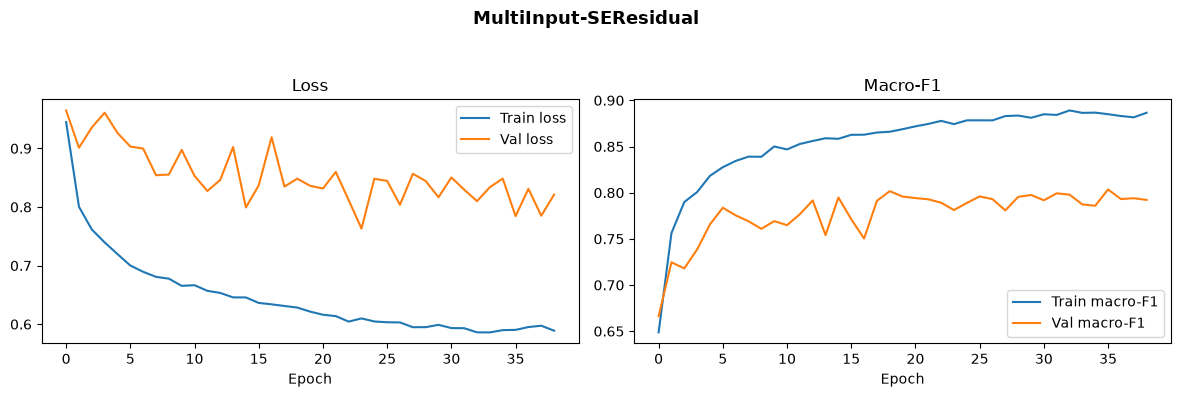

>>> Best checkpoint for MultiInput-SEResidual: epoch 24  (val_loss=0.7632, val_f1=0.7812)


In [25]:
torch.manual_seed(RANDOM_STATE)
seres_multi_model, seres_multi_f1, seres_multi_epoch = fit(
    MultiInputNet(
        metadata_dim=meta_train_final.shape[1],
        n_classes=len(season_encoder.classes_),
        image_encoder=SEResidualEncoder(out_dim=128)
    ).to(DEVICE),
    train_loader,
    val_loader,
    model_name='MultiInput-SEResidual'
)
results['MultiInput-SEResidual'] = (seres_multi_f1, seres_multi_epoch)


In [26]:
PRETRAINED_MODELS = {'ResNet18 (pretrained)', 'MobileNetV3-Small (pretrained)', 'MultiInput-ResNet18Pretrained'}
saveable_results = {k: v for k, v in results.items() if k not in PRETRAINED_MODELS}

best_name = max(saveable_results, key=lambda k: saveable_results[k][0])
best_f1, best_epoch_num = saveable_results[best_name]

print('=== Early-stopping checkpoint summary ===')
for name, (f1, epoch) in sorted(results.items(), key=lambda kv: -kv[1][0]):
    if name == best_name:
        marker = '  <-- best (saveable)'
    elif name in PRETRAINED_MODELS:
        marker = '  (pretrained -- excluded from saving)'
    else:
        marker = ''
    print(f'{name:35s}  val_f1={f1:.4f}  (best epoch: {epoch}){marker}')

print(f'\nBest performing SAVEABLE model: {best_name} (val_f1={best_f1:.4f} at epoch {best_epoch_num})')

=== Early-stopping checkpoint summary ===
MultiInput-ResNet18Pretrained        val_f1=0.8284  (best epoch: 33)  (pretrained -- excluded from saving)
MultiInput-ResNet18Scratch           val_f1=0.8196  (best epoch: 33)  <-- best (saveable)
MultiInput-ImprovedSmallCNN          val_f1=0.8082  (best epoch: 22)
MultiInput-SmallCNN                  val_f1=0.7889  (best epoch: 22)
MultiInput-SEResidual                val_f1=0.7812  (best epoch: 24)
ResNet18 (pretrained)                val_f1=0.7394  (best epoch: 12)  (pretrained -- excluded from saving)
ImprovedSmallCNN (image-only)        val_f1=0.7376  (best epoch: 25)
SEResidual (image-only)              val_f1=0.7206  (best epoch: 34)
SmallCNN (image-only)                val_f1=0.6556  (best epoch: 23)

Best performing SAVEABLE model: MultiInput-ResNet18Scratch (val_f1=0.8196 at epoch 33)


Image-only baselines:


,Train F1,Validation F1
Logistic Regression,0.7535,0.7418
ResNet18 (pretrained),0.9046,0.7394
SmallCNN (image-only),0.7266,0.6556
ImprovedSmallCNN (image-only),0.8895,0.7376
SEResidual (image-only),0.8612,0.7206



Multi-input models:


,Train F1,Validation F1
MultiInput-SmallCNN,0.8201,0.7889
MultiInput-ImprovedSmallCNN,0.8608,0.8082
MultiInput-SEResidual,0.8179,0.7812
MultiInput-ResNet18Scratch,0.9646,0.8196
MultiInput-ResNet18Pretrained,0.9815,0.8284


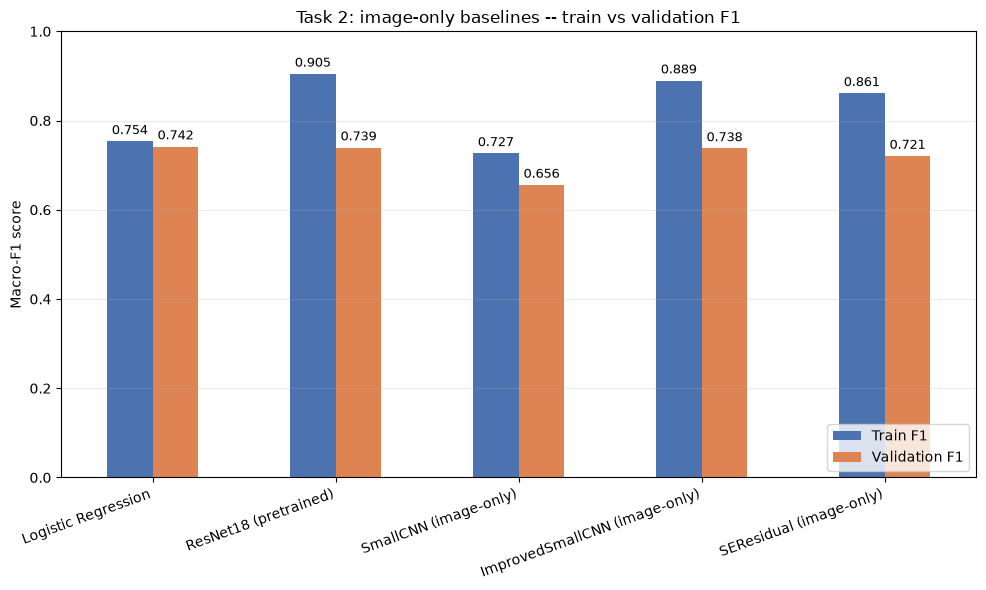

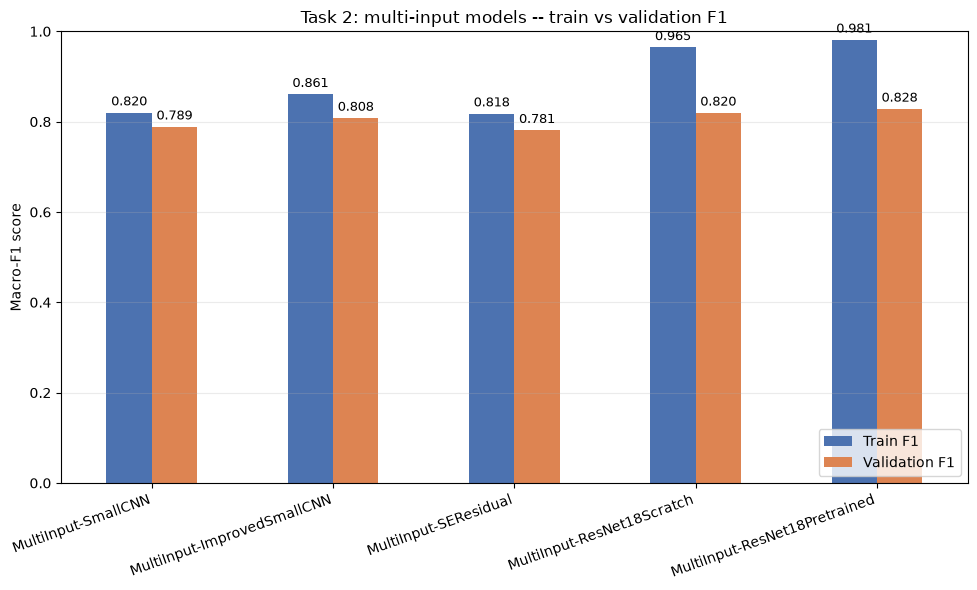

In [27]:
# Evaluate both splits and compare all models
multi_train_loader = DataLoader(
    MultiInputDataset(task2_train, meta_train_final, y_train, IMAGES_TRAIN_DIR, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

multi_val_loader = DataLoader(
    MultiInputDataset(task2_val, meta_val_final, y_val, IMAGES_TRAIN_DIR, eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ---- Image-only baselines ----
image_only_scores = pd.DataFrame({
    'Train F1': [
        logreg_train_f1,
        resnet_train_f1,
        small_cnn_img_only_train_f1,
        improved_small_cnn_img_only_train_f1,
        seres_img_only_train_f1,
    ],
    'Validation F1': [
        logreg_val_f1,
        resnet_val_f1,
        small_cnn_img_only_val_f1,
        improved_small_cnn_img_only_val_f1,
        seres_img_only_val_f1,
    ]
}, index=[
    'Logistic Regression',
    'ResNet18 (pretrained)',
    'SmallCNN (image-only)',
    'ImprovedSmallCNN (image-only)',
    'SEResidual (image-only)',
])

# ---- Multi-input models ----
multi_input_scores = pd.DataFrame({
    'Train F1': [
        evaluate(small_cnn_model, multi_train_loader),
        evaluate(improved_small_cnn_model, multi_train_loader),
        evaluate(seres_multi_model, multi_train_loader),
        evaluate(resnet_scratch_model, multi_train_loader),
        evaluate(resnet_pretrained_model, multi_train_loader),
    ],
    'Validation F1': [
        evaluate(small_cnn_model, multi_val_loader),
        evaluate(improved_small_cnn_model, multi_val_loader),
        evaluate(seres_multi_model, multi_val_loader),
        evaluate(resnet_scratch_model, multi_val_loader),
        evaluate(resnet_pretrained_model, multi_val_loader),
    ]
}, index=[
    'MultiInput-SmallCNN',
    'MultiInput-ImprovedSmallCNN',
    'MultiInput-SEResidual',
    'MultiInput-ResNet18Scratch',
    'MultiInput-ResNet18Pretrained',
])

print('Image-only baselines:')
display(image_only_scores.round(4))
print('\nMulti-input models:')
display(multi_input_scores.round(4))

# ---- Plots: one per group, so the two families aren't visually mixed together ----
for title, df in [('Task 2: image-only baselines', image_only_scores),
                   ('Task 2: multi-input models', multi_input_scores)]:
    ax = df.plot(kind='bar', figsize=(10, 6), ylim=(0, 1), rot=20, color=['#4C72B0', '#DD8452'])
    plt.ylabel('Macro-F1 score'); plt.title(f'{title} -- train vs validation F1'); plt.grid(axis='y', alpha=.25)
    plt.xticks(ha='right')
    plt.legend(loc='lower right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
    plt.tight_layout(); plt.show()

# ---- Combined table, for reference/export, still grouped ----
scores = pd.concat([image_only_scores, multi_input_scores], keys=['Image-only', 'Multi-input'])

As seen with the result, the best option for this task is MultiInput-ImprovedSmallCNN with validation F1 of 0.8063 F1 validation and overfit of 0.0597. This is lower than multi-input with ResNetScratch model which is a model using ResNet18 architecture without its pretrained weight. This does come with its drawbacks. The MultiInput-ImprovedSmallCNN needs correct metadata label or its’ performance will degrade. For cases where metadata isn’t available, image-only models will perform much more consistently. In this case, ImproveSmallCNN will be the model of choice because it has the highest validation F1 at 0.7261 while maintaining a decent overfit margin 0.1484. This is lower than pretrained ResNet18 at 0.7649 F1 validation but has a larger overfit gap at 0.1829. In conclusion, ImproveSmallCNN is the better option when no metadata is available, while MultiInput-ImproveSmallCNN performs better when metadata is present.

### Saving the best multi-input model
The models are saved to later loaded into a pipeline to generate metadata and do prediction on test set using multi-input model

In [28]:

multi_input_candidates = {
    'MultiInput-SmallCNN': (small_cnn_model, small_cnn_f1, SmallImageEncoder),
    'MultiInput-ResNet18Scratch': (resnet_scratch_model, resnet_scratch_f1, ResNet18Encoder),
    'MultiInput-ImprovedSmallCNN': (improved_small_cnn_model, improved_small_cnn_f1, ImprovedSmallImageEncoder),
    'MultiInput-SEResidual': (seres_multi_model, seres_multi_f1, SEResidualEncoder),
}

print('Multi-input candidates (validation macro-F1, from-scratch only):')
for name, (_, f1_val, _) in sorted(multi_input_candidates.items(), key=lambda kv: -kv[1][1]):
    print(f'  {name:32s} {f1_val:.4f}')

best_multi_name = max(multi_input_candidates, key=lambda k: multi_input_candidates[k][1])
best_multi_model, best_multi_f1, best_multi_encoder_cls = multi_input_candidates[best_multi_name]
print(f'\n>>> Best multi-input model: {best_multi_name} (val macro-F1 = {best_multi_f1:.4f})')
print(f'>>> For reference, the pretrained variant scored '
      f'{resnet_pretrained_f1:.4f} -- excluded from selection by the assignment rule.')

torch.save({
    'model_state_dict': best_multi_model.state_dict(),
    'model_name': best_multi_name,
    'image_encoder': best_multi_encoder_cls.__name__,
    'metadata_dim': int(meta_train_final.shape[1]),
    'n_classes': int(len(season_encoder.classes_)),
    'out_dim': 128,
    'val_f1': float(best_multi_f1),
    'pretrained': False,
}, OUTPUT_DIR / 'best_multiinput_task2.pt')

torch.save({
    'model_state_dict': improved_small_cnn_model.state_dict(),
    'model_name': 'MultiInput-ImprovedSmallCNN',
    'image_encoder': ImprovedSmallImageEncoder.__name__,
    'metadata_dim': int(meta_train_final.shape[1]),
    'n_classes': int(len(season_encoder.classes_)),
    'out_dim': 128,
    'val_f1': float(improved_small_cnn_f1),
}, OUTPUT_DIR / 'MultiInput-ImprovedSmallCNN-Task2.pt')

torch.save({
    'model_state_dict': small_cnn_model.state_dict(),
    'model_name': 'MultiInput-SmallCNN',
    'image_encoder': SmallImageEncoder.__name__,
    'metadata_dim': int(meta_train_final.shape[1]),
    'n_classes': int(len(season_encoder.classes_)),
    'out_dim': 128,
    'val_f1': float(small_cnn_f1),
}, OUTPUT_DIR / 'MultiInput-SmallCNN-Task2.pt')

joblib.dump(meta_preprocessor_final, OUTPUT_DIR / 'meta_preprocessor_task2.joblib')

# Reload check -- confirms the checkpoint reconstructs into a working model.
ckpt = torch.load(OUTPUT_DIR / 'best_multiinput_task2.pt', map_location=DEVICE)
reloaded = MultiInputNet(ckpt['metadata_dim'], ckpt['n_classes'],
                         best_multi_encoder_cls(out_dim=ckpt['out_dim'])).to(DEVICE)
reloaded.load_state_dict(ckpt['model_state_dict'])
print('Reload check: state dict loads cleanly into a fresh model.')
print('Saved:', OUTPUT_DIR / 'best_multiinput_task2.pt')
print('Saved:', OUTPUT_DIR / 'meta_preprocessor_task2.joblib',
      '(needed to rebuild the metadata vector at inference time)')


Multi-input candidates (validation macro-F1, from-scratch only):
  MultiInput-ResNet18Scratch       0.8196
  MultiInput-ImprovedSmallCNN      0.8082
  MultiInput-SmallCNN              0.7889
  MultiInput-SEResidual            0.7812

>>> Best multi-input model: MultiInput-ResNet18Scratch (val macro-F1 = 0.8196)
>>> For reference, the pretrained variant scored 0.8284 -- excluded from selection by the assignment rule.
Reload check: state dict loads cleanly into a fresh model.
Saved: ../outputs/task2_models/best_multiinput_task2.pt
Saved: ../outputs/task2_models/meta_preprocessor_task2.joblib (needed to rebuild the metadata vector at inference time)


## Part III: Error analysis

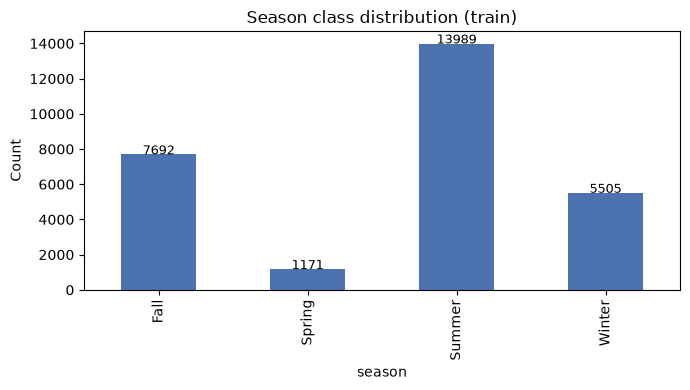

        count   pct
season             
Fall     7692  27.1
Spring   1171   4.1
Summer  13989  49.3
Winter   5505  19.4


In [29]:

# How imbalanced is the target, and does the imbalance carry over into predictions
fig, ax = plt.subplots(figsize=(7, 4))
class_counts = task2_train['season'].value_counts().reindex(season_encoder.classes_)
class_counts.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Season class distribution (train)')
ax.set_ylabel('Count')
for i, v in enumerate(class_counts):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

print(class_counts.to_frame('count').assign(pct=lambda d: (d['count']/d['count'].sum()*100).round(1)))

In [ ]:
# Pull per-class precision/recall/F1 out of the classification_report as a sortable table
improved_small_cnn_model_preds = []
improved_small_cnn_model.eval()
with torch.no_grad():
    for images, metadata, labels in multi_val_loader:
        images, metadata = images.to(DEVICE), metadata.to(DEVICE)
        preds = improved_small_cnn_model(images, metadata).argmax(dim=1).cpu().numpy()
        improved_small_cnn_model_preds.extend(preds)
improved_small_cnn_model_preds = np.array(improved_small_cnn_model_preds)

report_dict = classification_report(
    y_val, improved_small_cnn_model_preds, target_names=season_encoder.classes_, output_dict=True)
per_class = pd.DataFrame(report_dict).T.drop(['accuracy', 'macro avg', 'weighted avg'])
per_class = per_class.sort_values('f1-score')
display(per_class.round(3))

,precision,recall,f1-score,support
Spring,0.641,0.845,0.729,387.0
Fall,0.807,0.794,0.801,2563.0
Summer,0.856,0.829,0.842,4664.0
Winter,0.846,0.875,0.861,1837.0


In [ ]:

cm = confusion_matrix(y_val, improved_small_cnn_model_preds)
np.fill_diagonal(cm, 0)
pairs = []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > 0:
            pairs.append((season_encoder.classes_[i], season_encoder.classes_[j], cm[i, j]))
pairs_df = pd.DataFrame(pairs, columns=['True', 'Predicted', 'Count']).sort_values('Count', ascending=False)
display(pairs_df.head(10))

,True,Predicted,Count
1,Fall,Summer,453
6,Summer,Fall,427
8,Summer,Winter,243
11,Winter,Summer,159
7,Summer,Spring,127
9,Winter,Fall,46
2,Fall,Winter,42
4,Spring,Summer,39
0,Fall,Spring,32
10,Winter,Spring,24


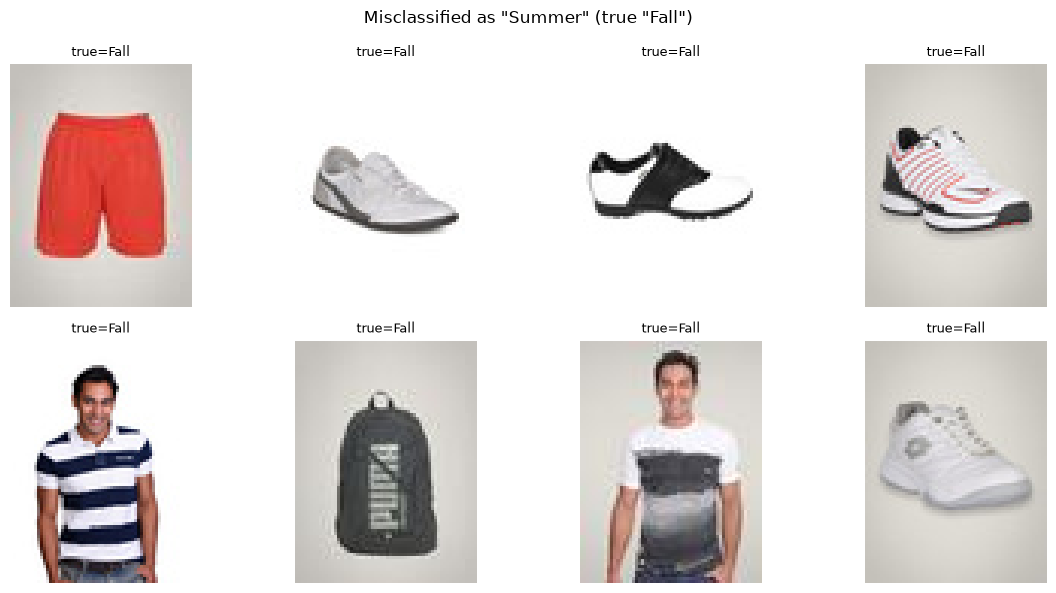

In [ ]:
# Grab a handful of misclassified images for the single worst confusion pair and look at them
worst_true, worst_pred = pairs_df.iloc[0][['True', 'Predicted']]
worst_true_enc = list(season_encoder.classes_).index(worst_true)
worst_pred_enc = list(season_encoder.classes_).index(worst_pred)

mask = (y_val == worst_true_enc) & (improved_small_cnn_model_preds == worst_pred_enc)
bad_rows = task2_val.reset_index(drop=True)[mask].head(8)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (_, row) in zip(axes.flat, bad_rows.iterrows()):
    with Image.open(IMAGES_TRAIN_DIR / f"{row['id']}.jpg") as im:
        ax.imshow(im)
    ax.set_title(f"true={worst_true}", fontsize=9)
    ax.axis('off')
fig.suptitle(f'Misclassified as "{worst_pred}" (true "{worst_true}")')
plt.tight_layout(); plt.show()

In [ ]:
val_full_season = val_usable['season'].reset_index(drop=True)
error_mask = (improved_small_cnn_model_preds != y_val)
error_rate_by_cat = (
    val_full_season.assign(error=error_mask)
    .groupby('masterCategory')['error']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'error_rate'})
    .sort_values('error_rate', ascending=False)
)
display(error_rate_by_cat.round(3))

,error_rate,count
masterCategory,,
Footwear,0.311,2127
Sporting Goods,0.167,6
Apparel,0.136,4602
Accessories,0.128,2446
Free Items,0.048,21
Personal Care,0.044,249


### Error analysis summary

The season classes are imbalanced: Summer is 49.3% of the training data, Fall 27.1%, Winter 19.4%, and Spring only 4.1%. This matches the per-class F1 results, Spring scores lowest (0.729), then Fall (0.801), Summer (0.842), and Winter (0.861).

The confusion matrix shows the model mixes up Fall and Summer the most: 453 Fall items were predicted as Summer, and 427 Summer items were predicted as Fall. This is by far the largest source of error. This can happen because many fashion items look similar enough in Fall and Summer that the image alone doesn't clearly separate them.

Further investigation of the errors by category shows Footwear has the highest error rate at 31.1%, compared to 13.6% for Apparel and 12.8% for Accessories. This makes sense because shoes often don't have a strong seasonal look, a pair of sneakers can pass for any season, while something like a winter coat looks obviously seasonal.

Overall, the errors aren't random, they're concentrated in the Fall,Summer confusion and in categories like Footwear where the image gives fewer seasonal clues.

## Part IV: Model improvement

An idea to improve the model performance was to add class weight loss since the original dataset have class imbalances within "season" attribute. This is been dealt with using weighted sampler but adding class weight loss as well might improve the model performance.

MultiInput-ImprovedSmallCNN (class-weighted) 1/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN (class-weighted) 1/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN (class-weighted) 2/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN (class-weighted) 2/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN (class-weighted) 3/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

...

MultiInput-ImprovedSmallCNN (class-weighted) 42/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN (class-weighted) 42/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN (class-weighted) 43/70 train:   0%|          | 0/444 [00:00<?, ?it/s]

MultiInput-ImprovedSmallCNN (class-weighted) 43/70 val:   0%|          | 0/148 [00:00<?, ?it/s]

Early stopping at epoch 43


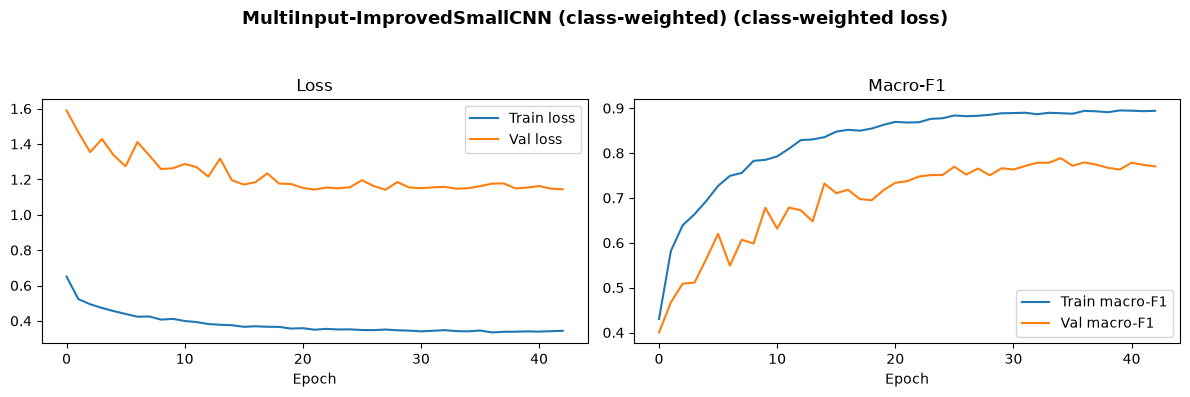

In [34]:
# Improvement experiment: does adding class-weighted CrossEntropyLoss on top of the
# WeightedRandomSampler help the minority classes the error analysis flagged as weak?
def fit_weighted(model, loader_tr, loader_va, class_weights_tensor, model_name='model',
                  patience=15, lr=3e-4, weight_decay=1e-4):
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE), label_smoothing=0.1)
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    early_stopping = EarlyStopping(patience=patience, delta=0.0, mode='min')
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = best_val_loss = best_epoch = None

    for epoch in range(EPOCHS):
        tag = f'{model_name} {epoch + 1}/{EPOCHS}'
        train_loss, train_f1 = run_epoch(model, loader_tr, criterion, optimiser, desc=f'{tag} train')
        val_loss, val_f1 = run_epoch(model, loader_va, criterion, None, desc=f'{tag} val')
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1); history['val_f1'].append(val_f1)
        scheduler.step(val_loss)
        if best_val_f1 is None or val_f1 > best_val_f1:
            best_val_f1, best_val_loss, best_epoch = val_f1, val_loss, epoch
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print(f'Early stopping at epoch {epoch+1}')
            break

    model = early_stopping.load_best_model(model)
    plot_training_curves(history, f'{model_name} (class-weighted loss)')
    return model, best_val_f1, best_epoch


torch.manual_seed(RANDOM_STATE)
improved_small_cnn_weighted_model, improved_small_cnn_weighted_f1, improved_small_cnn_weighted_epoch = fit_weighted(
    MultiInputNet(meta_train_final.shape[1], len(season_encoder.classes_), ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader, val_loader,
    class_weights_tensor=class_weights['season'],
    model_name='MultiInput-ImprovedSmallCNN (class-weighted)'
)

In [35]:
# Compare: macro-F1 AND per-class F1, since the whole point of this experiment is whether
# the weak minority classes specifically improved, not just the aggregate score.
weighted_val_preds = []
improved_small_cnn_weighted_model.eval()
with torch.no_grad():
    for images, metadata, labels in multi_val_loader:
        images, metadata = images.to(DEVICE), metadata.to(DEVICE)
        preds = improved_small_cnn_weighted_model(images, metadata).argmax(dim=1).cpu().numpy()
        weighted_val_preds.extend(preds)
weighted_val_preds = np.array(weighted_val_preds)

before = pd.DataFrame(classification_report(
    y_val, improved_small_cnn_model_preds, target_names=season_encoder.classes_, output_dict=True)).T
after = pd.DataFrame(classification_report(
    y_val, weighted_val_preds, target_names=season_encoder.classes_, output_dict=True)).T

comparison = pd.DataFrame({
    'F1 (sampler only)': before['f1-score'],
    'F1 (sampler + class-weighted loss)': after['f1-score'],
}).drop(['accuracy', 'macro avg', 'weighted avg'])
comparison['Δ'] = comparison['F1 (sampler + class-weighted loss)'] - comparison['F1 (sampler only)']
display(comparison.round(3).sort_values('Δ', ascending=False))

print(f"\nMacro-F1 before: {improved_small_cnn_f1:.4f}   after: {improved_small_cnn_weighted_f1:.4f}")

,F1 (sampler only),F1 (sampler + class-weighted loss),Δ
Fall,0.801,0.795,-0.005
Winter,0.861,0.844,-0.016
Summer,0.842,0.803,-0.039
Spring,0.729,0.620,-0.109



Macro-F1 before: 0.8082   after: 0.7887


As seen from the result with the experiment, add class-weighted loss didn't have much of an impact. It only lower F1 score from 0.8063 to 0.7887 (0.0195 difference). A likely explanation is that the WeightedRandomSampler used during training already rebalances how often each class is seen within a batch, so adding class-weighted loss on top still fix the same problem instead of something new. This can push the model to over-penalise confident, correct predictions on majority classes. Because of this, class-weighted loss was not adopted in the final model, and the sampler alone was kept as the imbalance-handling strategy.

## Reference:

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. In Proceedings of the 2016 IEEE Conference on Computer Vision and
Pattern Recognition (CVPR) (pp. 770–778). IEEE.  
Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). Applied logistic regression (3rd ed.). Wiley.  
Kelleher, J. D., Mac Namee, B., & D’Arcy, A. (2020). Fundamentals of Machine Learning for Predictive Data Analytics: Algorithms, worked examples, and case studies (Second Edition). The MIT Press.  
Potdar, K., Pardawala, T. S., & Pai, C. D. (2017). A comparative study of categorical variable encoding techniques for neural network classifiers. International Journal of Computer Applications, 175(4), 7–9.  
Powers, D. M. W. (2011). Evaluation: From precision, recall and F-measure to ROC, informedness, markedness and correlation. Journal of Machine Learning Technologies, 2(1), 37–63.

